# NOTE -
My modeling scripts basically do what I want for the time being, but there are major data integrity problems with Virginia resulting in massive errors. Also have not added demographic, education etc to this. Other notebook has census, copy it over here.

Have to tweak DataFrame names.

# Have to keep trying with validation, such as a GridSearchCV

# Also - Consider dropping columns for specific third parties, and putting all except Democratic and Republican into a single category.

In [89]:
import pandas as pd
import numpy as np

In [2]:
elections = pd.read_csv('/Users/matthewcavanaugh/Desktop/GitHub/us-presidential-elections-by-county/sources/countypres_2000-2020.csv')
elections

,year,state,state_po,county_name,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode
0,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,AL GORE,DEMOCRAT,4942,17208,20220315,TOTAL
1,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,GEORGE W. BUSH,REPUBLICAN,11993,17208,20220315,TOTAL
2,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,RALPH NADER,GREEN,160,17208,20220315,TOTAL
3,2000,ALABAMA,AL,AUTAUGA,1001.0,US PRESIDENT,OTHER,OTHER,113,17208,20220315,TOTAL
4,2000,ALABAMA,AL,BALDWIN,1003.0,US PRESIDENT,AL GORE,DEMOCRAT,13997,56480,20220315,TOTAL
...,...,...,...,...,...,...,...,...,...,...,...,...
72612,2020,WYOMING,WY,WASHAKIE,56043.0,US PRESIDENT,DONALD J TRUMP,REPUBLICAN,3245,4032,20220315,TOTAL
72613,2020,WYOMING,WY,WESTON,56045.0,US PRESIDENT,JOSEPH R BIDEN JR,DEMOCRAT,360,3560,20220315,TOTAL
72614,2020,WYOMING,WY,WESTON,56045.0,US PRESIDENT,JO JORGENSEN,LIBERTARIAN,46,3560,20220315,TOTAL
72615,2020,WYOMING,WY,WESTON,56045.0,US PRESIDENT,OTHER,OTHER,47,3560,20220315,TOTAL


EDA

In [3]:
elections.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72617 entries, 0 to 72616
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            72617 non-null  int64  
 1   state           72617 non-null  object 
 2   state_po        72617 non-null  object 
 3   county_name     72617 non-null  object 
 4   county_fips     72565 non-null  float64
 5   office          72617 non-null  object 
 6   candidate       72617 non-null  object 
 7   party           72617 non-null  object 
 8   candidatevotes  72617 non-null  int64  
 9   totalvotes      72617 non-null  int64  
 10  version         72617 non-null  int64  
 11  mode            72617 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 6.6+ MB


In [4]:
elections.isnull().sum()

year               0
state              0
state_po           0
county_name        0
county_fips       52
office             0
candidate          0
party              0
candidatevotes     0
totalvotes         0
version            0
mode               0
dtype: int64

Where are the nulls?

### Here we have examples of unusual reporting statistics.

In [5]:
elections[elections['county_fips'].isnull()]

,year,state,state_po,county_name,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode
12452,2000,CONNECTICUT,CT,STATEWIDE WRITEIN,NaN,US PRESIDENT,AL GORE,DEMOCRAT,0,0,20220315,TOTAL
12453,2000,MAINE,ME,MAINE UOCAVA,NaN,US PRESIDENT,AL GORE,DEMOCRAT,0,0,20220315,TOTAL
12454,2000,RHODE ISLAND,RI,FEDERAL PRECINCT,NaN,US PRESIDENT,AL GORE,DEMOCRAT,0,0,20220315,TOTAL
12455,2000,CONNECTICUT,CT,STATEWIDE WRITEIN,NaN,US PRESIDENT,GEORGE W. BUSH,REPUBLICAN,0,0,20220315,TOTAL
12456,2000,MAINE,ME,MAINE UOCAVA,NaN,US PRESIDENT,GEORGE W. BUSH,REPUBLICAN,0,0,20220315,TOTAL
12457,2000,RHODE ISLAND,RI,FEDERAL PRECINCT,NaN,US PRESIDENT,GEORGE W. BUSH,REPUBLICAN,0,0,20220315,TOTAL
12458,2000,CONNECTICUT,CT,STATEWIDE WRITEIN,NaN,US PRESIDENT,RALPH NADER,GREEN,0,0,20220315,TOTAL
12459,2000,MAINE,ME,MAINE UOCAVA,NaN,US PRESIDENT,RALPH NADER,GREEN,0,0,20220315,TOTAL
12460,2000,RHODE ISLAND,RI,FEDERAL PRECINCT,NaN,US PRESIDENT,RALPH NADER,GREEN,0,0,20220315,TOTAL
12461,2000,CONNECTICUT,CT,STATEWIDE WRITEIN,NaN,US PRESIDENT,OTHER,OTHER,0,0,20220315,TOTAL


These are unusual administrative units that have no votes recorded. It's safe to drop them.

In [6]:
elections.dropna(inplace=True)

In [7]:
# Combine 'County' and 'State' columns
#elections['county_name'] = elections['county_name'] + ', ' + elections['state']

#elections.drop('state', axis=1, inplace=True)
elections.drop('state_po', axis=1, inplace=True)
elections.drop('county_fips', axis=1, inplace=True)
elections.drop('office', axis=1, inplace=True)
elections.drop('version', axis=1, inplace=True)
elections.drop('mode', axis=1, inplace=True)
elections.drop('candidate', axis=1, inplace=True)

# Result
elections

,year,state,county_name,party,candidatevotes,totalvotes
0,2000,ALABAMA,AUTAUGA,DEMOCRAT,4942,17208
1,2000,ALABAMA,AUTAUGA,REPUBLICAN,11993,17208
2,2000,ALABAMA,AUTAUGA,GREEN,160,17208
3,2000,ALABAMA,AUTAUGA,OTHER,113,17208
4,2000,ALABAMA,BALDWIN,DEMOCRAT,13997,56480
...,...,...,...,...,...,...
72612,2020,WYOMING,WASHAKIE,REPUBLICAN,3245,4032
72613,2020,WYOMING,WESTON,DEMOCRAT,360,3560
72614,2020,WYOMING,WESTON,LIBERTARIAN,46,3560
72615,2020,WYOMING,WESTON,OTHER,47,3560


In [8]:
elections = elections.rename(columns={'year': 'Year'})
elections = elections.rename(columns={'state': 'State'})
elections = elections.rename(columns={'county_name': 'County'})
elections = elections.rename(columns={'state': 'State'})
elections = elections.rename(columns={'party': 'Party'})
elections = elections.rename(columns={'candidatevotes': 'Votes'})
elections = elections.rename(columns={'totalvotes': 'Total'})

elections

,Year,State,County,Party,Votes,Total
0,2000,ALABAMA,AUTAUGA,DEMOCRAT,4942,17208
1,2000,ALABAMA,AUTAUGA,REPUBLICAN,11993,17208
2,2000,ALABAMA,AUTAUGA,GREEN,160,17208
3,2000,ALABAMA,AUTAUGA,OTHER,113,17208
4,2000,ALABAMA,BALDWIN,DEMOCRAT,13997,56480
...,...,...,...,...,...,...
72612,2020,WYOMING,WASHAKIE,REPUBLICAN,3245,4032
72613,2020,WYOMING,WESTON,DEMOCRAT,360,3560
72614,2020,WYOMING,WESTON,LIBERTARIAN,46,3560
72615,2020,WYOMING,WESTON,OTHER,47,3560


In [9]:
def clean_text(text):
    if isinstance(text, str):
        return text.title()  # Capitalizes the first letter of each word and makes the rest lowercase
    return text  # Return text unchanged if it's not a string

# Apply this function to a specific column in your dataframe
elections['County'] = elections['County'].apply(clean_text)
elections['Party'] = elections['Party'].apply(clean_text)
elections['State'] = elections['State'].apply(clean_text)

In [10]:
elections

,Year,State,County,Party,Votes,Total
0,2000,Alabama,Autauga,Democrat,4942,17208
1,2000,Alabama,Autauga,Republican,11993,17208
2,2000,Alabama,Autauga,Green,160,17208
3,2000,Alabama,Autauga,Other,113,17208
4,2000,Alabama,Baldwin,Democrat,13997,56480
...,...,...,...,...,...,...
72612,2020,Wyoming,Washakie,Republican,3245,4032
72613,2020,Wyoming,Weston,Democrat,360,3560
72614,2020,Wyoming,Weston,Libertarian,46,3560
72615,2020,Wyoming,Weston,Other,47,3560


Virginia is an unusual case with many independent cities. Let's check it to ensure the capitlization has worked the way we want.

In [11]:
elections[elections['State'].str.contains('Virginia')]

,Year,State,County,Party,Votes,Total
11160,2000,Virginia,Accomack,Democrat,5092,11925
11161,2000,Virginia,Accomack,Republican,6352,11925
11162,2000,Virginia,Accomack,Green,220,11925
11163,2000,Virginia,Accomack,Other,261,11925
11164,2000,Virginia,Albemarle,Democrat,16255,36846
...,...,...,...,...,...,...
71965,2020,Virginia,Winchester City,Other,24,12113
71966,2020,Virginia,Winchester City,Other,0,12113
71967,2020,Virginia,Winchester City,Republican,2825,12113
71968,2020,Virginia,Winchester City,Republican,2370,12113


# Dropping problematic states
We will have to drop Virginia and Alaska for the time being for data integrity reasons. Virginia will likely be able to be re-added. Alaska may be trickier as it does not have consistent administrative units by which metrics are kept.

In [12]:
elections = elections[~elections['State'].str.contains('Virginia', na=False)]
elections = elections[~elections['State'].str.contains('Alaska', na=False)]

In [13]:
elections['Party'].value_counts()

Party
Democrat       19246
Republican     19246
Other          18210
Green           5706
Libertarian     4460
Name: count, dtype: int64

In [14]:
elections['Percentage'] = round((elections['Votes'] / elections['Total'] * 100), 2)
elections

,Year,State,County,Party,Votes,Total,Percentage
0,2000,Alabama,Autauga,Democrat,4942,17208,28.72
1,2000,Alabama,Autauga,Republican,11993,17208,69.69
2,2000,Alabama,Autauga,Green,160,17208,0.93
3,2000,Alabama,Autauga,Other,113,17208,0.66
4,2000,Alabama,Baldwin,Democrat,13997,56480,24.78
...,...,...,...,...,...,...,...
72612,2020,Wyoming,Washakie,Republican,3245,4032,80.48
72613,2020,Wyoming,Weston,Democrat,360,3560,10.11
72614,2020,Wyoming,Weston,Libertarian,46,3560,1.29
72615,2020,Wyoming,Weston,Other,47,3560,1.32


In [15]:
elections = elections[['Year', 'State', 'County', 'Party', 'Votes', 'Percentage', 'Total']]
elections

,Year,State,County,Party,Votes,Percentage,Total
0,2000,Alabama,Autauga,Democrat,4942,28.72,17208
1,2000,Alabama,Autauga,Republican,11993,69.69,17208
2,2000,Alabama,Autauga,Green,160,0.93,17208
3,2000,Alabama,Autauga,Other,113,0.66,17208
4,2000,Alabama,Baldwin,Democrat,13997,24.78,56480
...,...,...,...,...,...,...,...
72612,2020,Wyoming,Washakie,Republican,3245,80.48,4032
72613,2020,Wyoming,Weston,Democrat,360,10.11,3560
72614,2020,Wyoming,Weston,Libertarian,46,1.29,3560
72615,2020,Wyoming,Weston,Other,47,1.32,3560


In [16]:
# Pivot the DataFrame for vote totals by year and county for each party
vote_totals = elections.pivot_table(index=['Year', 'State', 'County'], columns='Party', values='Votes', aggfunc='sum')

# Pivot the DataFrame for percentages by year and county for each party
percentage_totals = elections.pivot_table(index=['Year', 'State', 'County'], columns='Party', values='Percentage', aggfunc='sum')

# Merge the two DataFrames together: vote totals and percentages
election_pivot = pd.concat([vote_totals, percentage_totals], axis=1, keys=['Votes', 'Percentage'])

# Flatten the MultiIndex columns and rename them according to the required format
election_pivot.columns = [f'{party} {stat}' for stat, party in election_pivot.columns]

# Reorder columns to keep the parties together (Democratic, Republican, etc.)
party_order = ['Democrat', 'Republican', 'Libertarian', 'Green', 'Other']  # You can add or adjust parties as needed
ordered_columns = []

for party in party_order:
    if f'{party} Votes' in election_pivot.columns:
        ordered_columns.append(f'{party} Votes')
    if f'{party} Percentage' in election_pivot.columns:
        ordered_columns.append(f'{party} Percentage')

# Reindex the DataFrame to match the desired column order
election_pivot = election_pivot[ordered_columns]

# Include the 'Total' column in the final DataFrame
election_results_totals = elections[['Year', 'State', 'County', 'Total']].drop_duplicates()

# Merge the 'Total' column back into the pivoted DataFrame
election_pivot = pd.merge(election_results_totals, election_pivot, on=['Year', 'State', 'County'])

# Move the 'Total' column to the end
election_pivot = election_pivot[[col for col in election_pivot.columns if col != 'Total'] + ['Total']]

# Fill nulls with 0
election_pivot.fillna(0, inplace=True)

# Display the pivoted DataFrame with the correct column ordering and Total column at the end
election_pivot

,Year,State,County,Democrat Votes,Democrat Percentage,Republican Votes,Republican Percentage,Libertarian Votes,Libertarian Percentage,Green Votes,Green Percentage,Other Votes,Other Percentage,Total
0,2000,Alabama,Autauga,4942.0,28.72,11993.0,69.69,0.0,0.00,160.0,0.93,113.0,0.66,17208
1,2000,Alabama,Baldwin,13997.0,24.78,40872.0,72.37,0.0,0.00,1033.0,1.83,578.0,1.02,56480
2,2000,Alabama,Barbour,5188.0,49.91,5096.0,49.02,0.0,0.00,46.0,0.44,65.0,0.63,10395
3,2000,Alabama,Bibb,2710.0,38.16,4273.0,60.17,0.0,0.00,52.0,0.73,66.0,0.93,7101
4,2000,Alabama,Blount,4977.0,27.69,12667.0,70.48,0.0,0.00,154.0,0.86,175.0,0.97,17973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17544,2020,Wyoming,Sweetwater,3823.0,22.89,12229.0,73.24,350.0,2.10,0.0,0.00,296.0,1.77,16698
17545,2020,Wyoming,Teton,9848.0,66.60,4341.0,29.36,255.0,1.72,0.0,0.00,343.0,2.32,14787
17546,2020,Wyoming,Uinta,1591.0,16.82,7496.0,79.25,172.0,1.82,0.0,0.00,200.0,2.11,9459
17547,2020,Wyoming,Washakie,651.0,16.15,3245.0,80.48,65.0,1.61,0.0,0.00,71.0,1.76,4032


In [17]:
election_pivot['D-R margin'] = election_pivot['Democrat Percentage'] - election_pivot['Republican Percentage']

In [18]:
election_pivot['Two party vote share'] = election_pivot['Democrat Percentage'] + election_pivot['Republican Percentage']

In [19]:
# Move the 'Total' column to the end
election_pivot = election_pivot[[col for col in election_pivot.columns if col != 'Total'] + ['Total']]

In [20]:
election_pivot

,Year,State,County,Democrat Votes,Democrat Percentage,Republican Votes,Republican Percentage,Libertarian Votes,Libertarian Percentage,Green Votes,Green Percentage,Other Votes,Other Percentage,D-R margin,Two party vote share,Total
0,2000,Alabama,Autauga,4942.0,28.72,11993.0,69.69,0.0,0.00,160.0,0.93,113.0,0.66,-40.97,98.41,17208
1,2000,Alabama,Baldwin,13997.0,24.78,40872.0,72.37,0.0,0.00,1033.0,1.83,578.0,1.02,-47.59,97.15,56480
2,2000,Alabama,Barbour,5188.0,49.91,5096.0,49.02,0.0,0.00,46.0,0.44,65.0,0.63,0.89,98.93,10395
3,2000,Alabama,Bibb,2710.0,38.16,4273.0,60.17,0.0,0.00,52.0,0.73,66.0,0.93,-22.01,98.33,7101
4,2000,Alabama,Blount,4977.0,27.69,12667.0,70.48,0.0,0.00,154.0,0.86,175.0,0.97,-42.79,98.17,17973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17544,2020,Wyoming,Sweetwater,3823.0,22.89,12229.0,73.24,350.0,2.10,0.0,0.00,296.0,1.77,-50.35,96.13,16698
17545,2020,Wyoming,Teton,9848.0,66.60,4341.0,29.36,255.0,1.72,0.0,0.00,343.0,2.32,37.24,95.96,14787
17546,2020,Wyoming,Uinta,1591.0,16.82,7496.0,79.25,172.0,1.82,0.0,0.00,200.0,2.11,-62.43,96.07,9459
17547,2020,Wyoming,Washakie,651.0,16.15,3245.0,80.48,65.0,1.61,0.0,0.00,71.0,1.76,-64.33,96.63,4032


In [21]:
election_pivot.nsmallest(10, 'Two party vote share')

,Year,State,County,Democrat Votes,Democrat Percentage,Republican Votes,Republican Percentage,Libertarian Votes,Libertarian Percentage,Green Votes,Green Percentage,Other Votes,Other Percentage,D-R margin,Two party vote share,Total
1797,2000,Missouri,Kansas City,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0
14449,2016,Utah,Cache,8563.0,18.55,21139.0,45.80,0.0,0.0,0.0,0.0,16455.0,35.65,-27.25,64.35,46157
12252,2016,Idaho,Madison,1201.0,7.66,8941.0,56.99,0.0,0.0,0.0,0.0,5546.0,35.35,-49.33,64.65,15688
14471,2016,Utah,Utah,28522.0,14.15,102182.0,50.70,0.0,0.0,0.0,0.0,70847.0,35.15,-36.55,64.85,201551
7828,2008,North Dakota,Grant,280.0,21.07,587.0,44.17,0.0,0.0,0.0,0.0,462.0,34.76,-23.10,65.24,1329
14452,2016,Utah,Davis,28776.0,20.79,62219.0,44.95,0.0,0.0,0.0,0.0,47416.0,34.26,-24.16,65.74,138411
7454,2008,Montana,Powder River,208.0,14.81,802.0,57.12,0.0,0.0,0.0,0.0,394.0,28.06,-42.31,71.93,1404
14469,2016,Utah,Tooele,4573.0,20.95,11169.0,51.17,0.0,0.0,0.0,0.0,6087.0,27.88,-30.22,72.12,21829
14461,2016,Utah,Morgan,577.0,11.11,3188.0,61.40,0.0,0.0,0.0,0.0,1427.0,27.48,-50.29,72.51,5192
14448,2016,Utah,Box Elder,2282.0,11.56,12230.0,61.97,0.0,0.0,0.0,0.0,5223.0,26.47,-50.41,73.53,19735


In some states in some years, certain minor parties did not file a candidate. However, it is suspicious if an entity has zero votes for either the Republican or Democratic parties. Let's drop those.

In [22]:
#This is just for debugging, can delete later
#election_pivot[election_pivot['State'].str.contains('Virginia')]

# Volatility
# For each county (i.e. State/County pair), find the average and total absolute swings between elections.
Add up the 2000-2004 swing, 2004-2008 swing, 2008-2012 swing, 2012-2016 swing, and 2016-2020 swing. This will identify *volatile* counties prone to large swings from year to year. A *volatile* county is not necessarily the same as a county that changes loyalty over time.

Something is weird in my calculations here.

May also want to calculate D and R votes as percentages of the two party vote.

In [23]:
election_copy = election_pivot.copy()
dupes = election_copy[election_copy.duplicated(subset=['County', 'State', 'Year'], keep=False)]

In [24]:
election_copy = election_copy.drop_duplicates(subset=['County', 'State', 'Year'])

In [25]:
election_copy['CountyState'] = election_copy['County'] + ', ' + election_copy['State']
county_swings = election_copy.pivot(index='CountyState', columns='Year', values='D-R margin')

In [26]:
county_swings

Year,2000,2004,2008,2012,2016,2020
CountyState,,,,,,
"Abbeville, South Carolina",-8.17,-10.55,-15.19,-13.48,-28.05,-33.08
"Acadia, Louisiana",-21.19,-28.33,-45.68,-49.82,-56.68,-60.34
"Ada, Idaho",-27.86,-23.30,-6.18,-11.31,-9.23,-3.92
"Adair, Iowa",-12.66,-13.05,-3.36,-8.11,-34.85,-41.28
"Adair, Kentucky",-50.23,-51.88,-52.67,-55.02,-64.54,-67.15
...,...,...,...,...,...,...
"Yuma, Arizona",-12.75,-15.99,-13.80,-12.61,-1.05,-6.19
"Yuma, Colorado",-47.59,-52.47,-48.38,-54.69,-65.21,-66.69
"Zapata, Texas",26.18,14.98,35.59,43.18,32.91,-5.35


In [ ]:
election_copy = election_pivot.copy()
dupes = election_copy[election_copy.duplicated(subset=['County', 'State', 'Year'], keep=False)]
election_copy = election_copy.drop_duplicates(subset=['County', 'State', 'Year'])
election_copy['CountyState'] = election_copy['County'] + ', ' + election_copy['State']
county_swings = election_copy.pivot(index='CountyState', columns='Year', values='D-R margin')
county_swings

In [138]:
election_copy = election_pivot.copy()

# Find duplicates based on County, State, Year
dupes = election_copy[election_copy.duplicated(subset=['County', 'State', 'Year'], keep=False)]

# Drop duplicates based on County, State, Year
election_copy = election_copy.drop_duplicates(subset=['County', 'State', 'Year'])

# Create the pivot table indexed by County and State, columns = Year, values = 'D-R margin'
county_swings = election_copy.pivot_table(index=['County', 'State'], columns='Year', values='D-R margin')

county_swings

Year                       2000   2004   2008   2012   2016   2020
County    State                                                   
Abbeville South Carolina  -8.17 -10.55 -15.19 -13.48 -28.05 -33.08
Acadia    Louisiana      -21.19 -28.33 -45.68 -49.82 -56.68 -60.34
Ada       Idaho          -27.86 -23.30  -6.18 -11.31  -9.23  -3.92
Adair     Iowa           -12.66 -13.05  -3.36  -8.11 -34.85 -41.28
          Kentucky       -50.23 -51.88 -52.67 -55.02 -64.54 -67.15
...                         ...    ...    ...    ...    ...    ...
Yuma      Arizona        -12.75 -15.99 -13.80 -12.61  -1.05  -6.19
          Colorado       -47.59 -52.47 -48.38 -54.69 -65.21 -66.69
Zapata    Texas           26.18  14.98  35.59  43.18  32.91  -5.35
Zavala    Texas           55.00  49.87  68.80  67.56  57.18  31.37
Ziebach   South Dakota    -9.71  17.39  27.44  16.43  -1.96   8.50

[2927 rows x 6 columns]

In [141]:
election_copy = election_pivot.copy()

# Identify and drop duplicates based on County, State, and Year
election_copy = election_copy.drop_duplicates(subset=['County', 'State', 'Year'])

# Create pivot with County and State retained as columns
pivot_table = election_copy.pivot(index=['County', 'State'], columns='Year', values='D-R margin').reset_index()

# Merge pivoted data back onto original index using County and State as keys
county_swings = election_copy[['County', 'State']].drop_duplicates().merge(pivot_table, on=['County', 'State'], how='left')

# Reindex to preserve original index (optional, if original index was meaningful)
#county_swings.index = election_copy.drop_duplicates(subset=['County', 'State'])[['County', 'State']].index

county_swings

,County,State,2000,2004,2008,2012,2016,2020
0,Autauga,Alabama,-40.97,-51.98,-47.84,-46.03,-49.00,-44.42
1,Baldwin,Alabama,-47.59,-53.92,-51.45,-55.77,-57.16,-53.76
2,Barbour,Alabama,0.89,-9.90,-1.45,3.15,-5.57,-7.66
3,Bibb,Alabama,-22.01,-44.51,-45.84,-46.68,-55.15,-57.73
4,Blount,Alabama,-42.79,-62.54,-69.51,-74.10,-80.90,-80.00
...,...,...,...,...,...,...,...,...
2922,Washakie,Wyoming,-57.56,-57.00,-46.69,-56.29,-62.37,-64.33
2923,Weston,Wyoming,-67.72,-63.65,-57.41,-71.42,-77.54,-77.17
2924,Broomfield,Colorado,NaN,-4.62,11.58,5.97,14.23,27.41
2925,Oglala Lakota,South Dakota,NaN,NaN,NaN,NaN,78.10,79.13


In [142]:
county_swings['2000-2004 swing'] = county_swings[2004] - county_swings[2000]
county_swings['2000-2004 absolute swing'] = county_swings['2000-2004 swing'].abs()
county_swings['2004-2008 swing'] = county_swings[2008] - county_swings[2004]
county_swings['2004-2008 absolute swing'] = county_swings['2004-2008 swing'].abs()
county_swings['2008-2012 swing'] = county_swings[2012] - county_swings[2008]
county_swings['2008-2012 absolute swing'] = county_swings['2008-2012 swing'].abs()
county_swings['2012-2016 swing'] = county_swings[2016] - county_swings[2012]
county_swings['2012-2016 absolute swing'] = county_swings['2012-2016 swing'].abs()
county_swings['2016-2020 swing'] = county_swings[2020] - county_swings[2016]
county_swings['2016-2020 absolute swing'] = county_swings['2016-2020 swing'].abs()

In [143]:
county_swings['Long term overall change'] = county_swings['2000-2004 swing'] + county_swings['2004-2008 swing'] + county_swings['2008-2012 swing'] + county_swings['2012-2016 swing'] + county_swings['2016-2020 swing']
county_swings['Long term absolute change'] = county_swings['Long term overall change'].abs()
county_swings['Volatility'] = county_swings['2000-2004 absolute swing'] + county_swings['2004-2008 absolute swing'] + county_swings['2008-2012 absolute swing'] + county_swings['2012-2016 absolute swing'] + county_swings['2016-2020 absolute swing']

In [144]:
county_swings['Long term absolute change'] = pd.to_numeric(
    county_swings['Long term absolute change'], errors='coerce'
)

In [145]:
county_swings['Volatility minus absolute change'] = (
    county_swings['Volatility'] - county_swings['Long term absolute change']
)

In [146]:
county_swings['Volatility div absolute change'] = (
    county_swings['Volatility'] / county_swings['Long term absolute change']
)

In [147]:
county_swings

,County,State,2000,2004,2008,2012,2016,2020,2000-2004 swing,2000-2004 absolute swing,...,2008-2012 absolute swing,2012-2016 swing,2012-2016 absolute swing,2016-2020 swing,2016-2020 absolute swing,Long term overall change,Long term absolute change,Volatility,Volatility minus absolute change,Volatility div absolute change
0,Autauga,Alabama,-40.97,-51.98,-47.84,-46.03,-49.00,-44.42,-11.01,11.01,...,1.81,-2.97,2.97,4.58,4.58,-3.45,3.45,24.51,21.06,7.104348
1,Baldwin,Alabama,-47.59,-53.92,-51.45,-55.77,-57.16,-53.76,-6.33,6.33,...,4.32,-1.39,1.39,3.40,3.40,-6.17,6.17,17.91,11.74,2.902755
2,Barbour,Alabama,0.89,-9.90,-1.45,3.15,-5.57,-7.66,-10.79,10.79,...,4.60,-8.72,8.72,-2.09,2.09,-8.55,8.55,34.65,26.10,4.052632
3,Bibb,Alabama,-22.01,-44.51,-45.84,-46.68,-55.15,-57.73,-22.50,22.50,...,0.84,-8.47,8.47,-2.58,2.58,-35.72,35.72,35.72,0.00,1.000000
4,Blount,Alabama,-42.79,-62.54,-69.51,-74.10,-80.90,-80.00,-19.75,19.75,...,4.59,-6.80,6.80,0.90,0.90,-37.21,37.21,39.01,1.80,1.048374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,Washakie,Wyoming,-57.56,-57.00,-46.69,-56.29,-62.37,-64.33,0.56,0.56,...,9.60,-6.08,6.08,-1.96,1.96,-6.77,6.77,28.51,21.74,4.211226
2923,Weston,Wyoming,-67.72,-63.65,-57.41,-71.42,-77.54,-77.17,4.07,4.07,...,14.01,-6.12,6.12,0.37,0.37,-9.45,9.45,30.81,21.36,3.260317
2924,Broomfield,Colorado,NaN,-4.62,11.58,5.97,14.23,27.41,NaN,NaN,...,5.61,8.26,8.26,13.18,13.18,NaN,NaN,NaN,NaN,NaN
2925,Oglala Lakota,South Dakota,NaN,NaN,NaN,NaN,78.10,79.13,NaN,NaN,...,NaN,NaN,NaN,1.03,1.03,NaN,NaN,NaN,NaN,NaN


# Adjusted volatility score.

In addition to base volatility, this adjusted metric considers the following:

Volatility minus absolute change - A larger number indicates a county that is prone to large swings from one election to the next, but in 2020 ended up back at the same place it was in 2000.

Volatility div absolute change - Similar to above. This metric is further divided by 100.

2016-2020 absolute swing - This is already factored into the base volatility score, but is added again to reflect counties that shifted recently and thus may be seeking alternatives.


# Later - take adjusted volatility score, add modeling errors, and TV market price, to find good targest for a third party.

In [150]:
county_swings['Adjusted volatility score'] = (
    county_swings['Volatility'] + 
    county_swings['2016-2020 absolute swing'] + 
    county_swings['Volatility minus absolute change'] +
    (county_swings['Volatility div absolute change'] / 100)
)

In [151]:
county_swings

,County,State,2000,2004,2008,2012,2016,2020,2000-2004 swing,2000-2004 absolute swing,...,2012-2016 swing,2012-2016 absolute swing,2016-2020 swing,2016-2020 absolute swing,Long term overall change,Long term absolute change,Volatility,Volatility minus absolute change,Volatility div absolute change,Adjusted volatility score
0,Autauga,Alabama,-40.97,-51.98,-47.84,-46.03,-49.00,-44.42,-11.01,11.01,...,-2.97,2.97,4.58,4.58,-3.45,3.45,24.51,21.06,7.104348,50.221043
1,Baldwin,Alabama,-47.59,-53.92,-51.45,-55.77,-57.16,-53.76,-6.33,6.33,...,-1.39,1.39,3.40,3.40,-6.17,6.17,17.91,11.74,2.902755,33.079028
2,Barbour,Alabama,0.89,-9.90,-1.45,3.15,-5.57,-7.66,-10.79,10.79,...,-8.72,8.72,-2.09,2.09,-8.55,8.55,34.65,26.10,4.052632,62.880526
3,Bibb,Alabama,-22.01,-44.51,-45.84,-46.68,-55.15,-57.73,-22.50,22.50,...,-8.47,8.47,-2.58,2.58,-35.72,35.72,35.72,0.00,1.000000,38.310000
4,Blount,Alabama,-42.79,-62.54,-69.51,-74.10,-80.90,-80.00,-19.75,19.75,...,-6.80,6.80,0.90,0.90,-37.21,37.21,39.01,1.80,1.048374,41.720484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,Washakie,Wyoming,-57.56,-57.00,-46.69,-56.29,-62.37,-64.33,0.56,0.56,...,-6.08,6.08,-1.96,1.96,-6.77,6.77,28.51,21.74,4.211226,52.252112
2923,Weston,Wyoming,-67.72,-63.65,-57.41,-71.42,-77.54,-77.17,4.07,4.07,...,-6.12,6.12,0.37,0.37,-9.45,9.45,30.81,21.36,3.260317,52.572603
2924,Broomfield,Colorado,NaN,-4.62,11.58,5.97,14.23,27.41,NaN,NaN,...,8.26,8.26,13.18,13.18,NaN,NaN,NaN,NaN,NaN,NaN
2925,Oglala Lakota,South Dakota,NaN,NaN,NaN,NaN,78.10,79.13,NaN,NaN,...,NaN,NaN,1.03,1.03,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
county_swings['Adjusted volatility score'].nlargest(20)

CountyState
Bayfield, Wisconsin            inf
Maverick, Texas         223.366252
Starr, Texas            207.710477
Zapata, Texas           182.617888
Morgan, Utah            178.194798
Cache, Utah             175.476970
Culberson, Texas        174.111838
Benson, North Dakota    171.964290
Tooele, Utah            171.529565
Willacy, Texas          171.240160
Box Elder, Utah         169.372121
Madison, Idaho          167.833653
Jim Hogg, Texas         167.442511
Webb, Texas             165.688892
Edwards, Texas          165.222582
Reeves, Texas           158.840180
Steele, North Dakota    156.188007
Hidalgo, Texas          156.059465
Sanpete, Utah           154.804213
Grant, North Dakota     153.700493
Name: Adjusted volatility score, dtype: float64

# DataFrames for each individual election.

In [36]:
election2000 = election_pivot[election_pivot['Year'] == 2000]
election2004 = election_pivot[election_pivot['Year'] == 2004]
election2008 = election_pivot[election_pivot['Year'] == 2008]
election2012 = election_pivot[election_pivot['Year'] == 2012]
election2016 = election_pivot[election_pivot['Year'] == 2016]
election2020 = election_pivot[election_pivot['Year'] == 2020]

In [37]:
election2016.nsmallest(10, 'Two party vote share')

,Year,State,County,Democrat Votes,Democrat Percentage,Republican Votes,Republican Percentage,Libertarian Votes,Libertarian Percentage,Green Votes,Green Percentage,Other Votes,Other Percentage,D-R margin,Two party vote share,Total
14449,2016,Utah,Cache,8563.0,18.55,21139.0,45.80,0.0,0.0,0.0,0.0,16455.0,35.65,-27.25,64.35,46157
12252,2016,Idaho,Madison,1201.0,7.66,8941.0,56.99,0.0,0.0,0.0,0.0,5546.0,35.35,-49.33,64.65,15688
14471,2016,Utah,Utah,28522.0,14.15,102182.0,50.70,0.0,0.0,0.0,0.0,70847.0,35.15,-36.55,64.85,201551
14452,2016,Utah,Davis,28776.0,20.79,62219.0,44.95,0.0,0.0,0.0,0.0,47416.0,34.26,-24.16,65.74,138411
14469,2016,Utah,Tooele,4573.0,20.95,11169.0,51.17,0.0,0.0,0.0,0.0,6087.0,27.88,-30.22,72.12,21829
14461,2016,Utah,Morgan,577.0,11.11,3188.0,61.40,0.0,0.0,0.0,0.0,1427.0,27.48,-50.29,72.51,5192
14448,2016,Utah,Box Elder,2282.0,11.56,12230.0,61.97,0.0,0.0,0.0,0.0,5223.0,26.47,-50.41,73.53,19735
14475,2016,Utah,Weber,23131.0,27.20,40235.0,47.31,0.0,0.0,0.0,0.0,21673.0,25.49,-20.11,74.51,85039
14464,2016,Utah,Salt Lake,175863.0,41.99,138043.0,32.96,0.0,0.0,0.0,0.0,104962.0,25.06,9.03,74.95,418868
14472,2016,Utah,Wasatch,3063.0,25.27,6115.0,50.45,0.0,0.0,0.0,0.0,2942.0,24.27,-25.18,75.72,12120


# Machine Learning

For each election, we will predict each party's vote share.

Using data from the other elections.

Three models.

We will break down results by county, state, year.

In [73]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression


from sklearn.ensemble import GradientBoostingRegressor


from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import ExtraTreesRegressor

Each model will follow the same basic steps:
1. Model selection and tuning. The model will initially be trained on the full 2000-2020 dataset with an 80/20 train/test split, and a GridSearchCV will be employed to find the best hyperparameters.
2. Once the best hyperparameters are determined, the model will simulate each election individually, using the others as training. This will effectively create an 83/17 split.
3. The results of each model will be aggregated by county, state, and year.
4. When all models have been run, the results of each will be compiled into a single dataframe.

# Model 1: Random Forest Regressor

### 1A: Finding the best model

GridSearch

In [59]:
election_pivot

,Year,State,County,Democrat Votes,Democrat Percentage,Republican Votes,Republican Percentage,Libertarian Votes,Libertarian Percentage,Green Votes,Green Percentage,Other Votes,Other Percentage,D-R margin,Two party vote share,Total
0,2000,Alabama,Autauga,4942.0,28.72,11993.0,69.69,0.0,0.00,160.0,0.93,113.0,0.66,-40.97,98.41,17208
1,2000,Alabama,Baldwin,13997.0,24.78,40872.0,72.37,0.0,0.00,1033.0,1.83,578.0,1.02,-47.59,97.15,56480
2,2000,Alabama,Barbour,5188.0,49.91,5096.0,49.02,0.0,0.00,46.0,0.44,65.0,0.63,0.89,98.93,10395
3,2000,Alabama,Bibb,2710.0,38.16,4273.0,60.17,0.0,0.00,52.0,0.73,66.0,0.93,-22.01,98.33,7101
4,2000,Alabama,Blount,4977.0,27.69,12667.0,70.48,0.0,0.00,154.0,0.86,175.0,0.97,-42.79,98.17,17973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17544,2020,Wyoming,Sweetwater,3823.0,22.89,12229.0,73.24,350.0,2.10,0.0,0.00,296.0,1.77,-50.35,96.13,16698
17545,2020,Wyoming,Teton,9848.0,66.60,4341.0,29.36,255.0,1.72,0.0,0.00,343.0,2.32,37.24,95.96,14787
17546,2020,Wyoming,Uinta,1591.0,16.82,7496.0,79.25,172.0,1.82,0.0,0.00,200.0,2.11,-62.43,96.07,9459
17547,2020,Wyoming,Washakie,651.0,16.15,3245.0,80.48,65.0,1.61,0.0,0.00,71.0,1.76,-64.33,96.63,4032


In [42]:
#rfc_gs = GridSearchCV(RandomForestClassifier(), rfc_params, cv=5, verbose=1)

In [49]:
X = election_pivot.drop(columns=['State', 'County', 'D-R margin'])
y = election_pivot['D-R margin']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=9)

In [60]:
rfr = RandomForestRegressor(random_state=42)

In [52]:
rfr_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [55]:
rfr_gs = GridSearchCV(RandomForestRegressor(random_state=42), rfr_params, cv=5, verbose=1)

In [56]:
%%time
rfr_gs.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("MAE on test set:", mean_absolute_error(y_test, y_pred))
print("R² on test set:", r2_score(y_test, y_pred))

### 1B: Predicting individual elections
Dataframes will be created for each election. Each cell may take about 10-15 seconds to run.

In [48]:
# Run this cell to predict 2000 with the Random Forest Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2000) and test (2000)
train_data_rfr_2000 = election_pivot[election_pivot['Year'] != 2000]
test_data_rfr_2000 = election_pivot[election_pivot['Year'] == 2000]

# Prepare X (features) and y (targets)
X_train_rfr_2000, y_train_rfr_2000 = train_data_rfr_2000[features], train_data_rfr_2000[targets]
X_test_rfr_2000, y_test_rfr_2000 = test_data_rfr_2000[features], test_data_rfr_2000[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_rfr_2000, y_train_rfr_2000)

# Predict for 2000
y_pred_rfr_2000 = rfr.predict(X_test_rfr_2000)

# Convert predictions to DataFrame
y_pred_rfr_df_2000 = pd.DataFrame(y_pred_rfr_2000, index=test_data_rfr_2000.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
rfr_comparison_2000 = pd.concat([test_data_rfr_2000[['State', 'County'] + targets], y_pred_rfr_df_2000], axis=1)

# Rename actual columns for clarity
rfr_comparison_2000.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    rfr_comparison_2000[f'{party} Error'] = rfr_comparison_2000[f'Predicted {party} Percentage'] - rfr_comparison_2000[f'Actual {party} Percentage']
    rfr_comparison_2000[f'{party} Absolute Error'] = rfr_comparison_2000[f'{party} Error'].abs()

# Party averages and totals
rfr_comparison_2000['Two Party Average Absolute Error'] = ((rfr_comparison_2000['Democrat Absolute Error'] + rfr_comparison_2000['Republican Absolute Error']) / 2).abs()

In [49]:
# Run this cell to predict 2004 with the Random Forest Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2004) and test (2004)
train_data_rfr_2004 = election_pivot[election_pivot['Year'] != 2004]
test_data_rfr_2004 = election_pivot[election_pivot['Year'] == 2004]

# Prepare X (features) and y (targets)
X_train_rfr_2004, y_train_rfr_2004 = train_data_rfr_2004[features], train_data_rfr_2004[targets]
X_test_rfr_2004, y_test_rfr_2004 = test_data_rfr_2004[features], test_data_rfr_2004[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_rfr_2004, y_train_rfr_2004)

# Predict for 2004
y_pred_rfr_2004 = rfr.predict(X_test_rfr_2004)

# Convert predictions to DataFrame
y_pred_rfr_df_2004 = pd.DataFrame(y_pred_rfr_2004, index=test_data_rfr_2004.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
rfr_comparison_2004 = pd.concat([test_data_rfr_2004[['State', 'County'] + targets], y_pred_rfr_df_2004], axis=1)

# Rename actual columns for clarity
rfr_comparison_2004.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    rfr_comparison_2004[f'{party} Error'] = rfr_comparison_2004[f'Predicted {party} Percentage'] - rfr_comparison_2004[f'Actual {party} Percentage']
    rfr_comparison_2004[f'{party} Absolute Error'] = rfr_comparison_2004[f'{party} Error'].abs()

# Party averages and totals
rfr_comparison_2004['Two Party Average Absolute Error'] = ((rfr_comparison_2004['Democrat Absolute Error'] + rfr_comparison_2004['Republican Absolute Error']) / 2).abs()

In [50]:
# Run this cell to predict 2008 with the Random Forest Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2008) and test (2008)
train_data_rfr_2008 = election_pivot[election_pivot['Year'] != 2008]
test_data_rfr_2008 = election_pivot[election_pivot['Year'] == 2008]

# Prepare X (features) and y (targets)
X_train_rfr_2008, y_train_rfr_2008 = train_data_rfr_2008[features], train_data_rfr_2008[targets]
X_test_rfr_2008, y_test_rfr_2008 = test_data_rfr_2008[features], test_data_rfr_2008[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_rfr_2008, y_train_rfr_2008)

# Predict for 2008
y_pred_rfr_2008 = rfr.predict(X_test_rfr_2008)

# Convert predictions to DataFrame
y_pred_rfr_df_2008 = pd.DataFrame(y_pred_rfr_2008, index=test_data_rfr_2008.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
rfr_comparison_2008 = pd.concat([test_data_rfr_2008[['State', 'County'] + targets], y_pred_rfr_df_2008], axis=1)

# Rename actual columns for clarity
rfr_comparison_2008.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    rfr_comparison_2008[f'{party} Error'] = rfr_comparison_2008[f'Predicted {party} Percentage'] - rfr_comparison_2008[f'Actual {party} Percentage']
    rfr_comparison_2008[f'{party} Absolute Error'] = rfr_comparison_2008[f'{party} Error'].abs()

# Party averages and totals
rfr_comparison_2008['Two Party Average Absolute Error'] = ((rfr_comparison_2008['Democrat Absolute Error'] + rfr_comparison_2008['Republican Absolute Error']) / 2).abs()

In [51]:
# Run this cell to predict 2012 with the Random Forest Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2012) and test (2012)
train_data_rfr_2012 = election_pivot[election_pivot['Year'] != 2012]
test_data_rfr_2012 = election_pivot[election_pivot['Year'] == 2012]

# Prepare X (features) and y (targets)
X_train_rfr_2012, y_train_rfr_2012 = train_data_rfr_2012[features], train_data_rfr_2012[targets]
X_test_rfr_2012, y_test_rfr_2012 = test_data_rfr_2012[features], test_data_rfr_2012[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_rfr_2012, y_train_rfr_2012)

# Predict for 2012
y_pred_rfr_2012 = rfr.predict(X_test_rfr_2012)

# Convert predictions to DataFrame
y_pred_rfr_df_2012 = pd.DataFrame(y_pred_rfr_2012, index=test_data_rfr_2012.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
rfr_comparison_2012 = pd.concat([test_data_rfr_2012[['State', 'County'] + targets], y_pred_rfr_df_2012], axis=1)

# Rename actual columns for clarity
rfr_comparison_2012.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    rfr_comparison_2012[f'{party} Error'] = rfr_comparison_2012[f'Predicted {party} Percentage'] - rfr_comparison_2012[f'Actual {party} Percentage']
    rfr_comparison_2012[f'{party} Absolute Error'] = rfr_comparison_2012[f'{party} Error'].abs()

# Party averages and totals
rfr_comparison_2012['Two Party Average Absolute Error'] = ((rfr_comparison_2012['Democrat Absolute Error'] + rfr_comparison_2012['Republican Absolute Error']) / 2).abs()

In [52]:
# Run this cell to predict 2016 with the Random Forest Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2016) and test (2016)
train_data_rfr_2016 = election_pivot[election_pivot['Year'] != 2016]
test_data_rfr_2016 = election_pivot[election_pivot['Year'] == 2016]

# Prepare X (features) and y (targets)
X_train_rfr_2016, y_train_rfr_2016 = train_data_rfr_2016[features], train_data_rfr_2016[targets]
X_test_rfr_2016, y_test_rfr_2016 = test_data_rfr_2016[features], test_data_rfr_2016[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_rfr_2016, y_train_rfr_2016)

# Predict for 2016
y_pred_rfr_2016 = rfr.predict(X_test_rfr_2016)

# Convert predictions to DataFrame
y_pred_rfr_df_2016 = pd.DataFrame(y_pred_rfr_2016, index=test_data_rfr_2016.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
rfr_comparison_2016 = pd.concat([test_data_rfr_2016[['State', 'County'] + targets], y_pred_rfr_df_2016], axis=1)

# Rename actual columns for clarity
rfr_comparison_2016.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    rfr_comparison_2016[f'{party} Error'] = rfr_comparison_2016[f'Predicted {party} Percentage'] - rfr_comparison_2016[f'Actual {party} Percentage']
    rfr_comparison_2016[f'{party} Absolute Error'] = rfr_comparison_2016[f'{party} Error'].abs()

# Party averages and totals
rfr_comparison_2016['Two Party Average Absolute Error'] = ((rfr_comparison_2016['Democrat Absolute Error'] + rfr_comparison_2016['Republican Absolute Error']) / 2).abs()

In [53]:
# Run this cell to predict 2020 with the Random Forest Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2020) and test (2020)
train_data_rfr_2020 = election_pivot[election_pivot['Year'] != 2020]
test_data_rfr_2020 = election_pivot[election_pivot['Year'] == 2020]

# Prepare X (features) and y (targets)
X_train_rfr_2020, y_train_rfr_2020 = train_data_rfr_2020[features], train_data_rfr_2020[targets]
X_test_rfr_2020, y_test_rfr_2020 = test_data_rfr_2020[features], test_data_rfr_2020[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_rfr_2020, y_train_rfr_2020)

# Predict for 2020
y_pred_rfr_2020 = rfr.predict(X_test_rfr_2020)

# Convert predictions to DataFrame
y_pred_rfr_df_2020 = pd.DataFrame(y_pred_rfr_2020, index=test_data_rfr_2020.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
rfr_comparison_2020 = pd.concat([test_data_rfr_2020[['State', 'County'] + targets], y_pred_rfr_df_2020], axis=1)

# Rename actual columns for clarity
rfr_comparison_2020.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    rfr_comparison_2020[f'{party} Error'] = rfr_comparison_2020[f'Predicted {party} Percentage'] - rfr_comparison_2020[f'Actual {party} Percentage']
    rfr_comparison_2020[f'{party} Absolute Error'] = rfr_comparison_2020[f'{party} Error'].abs()

# Party averages and totals
rfr_comparison_2020['Two Party Average Absolute Error'] = ((rfr_comparison_2020['Democrat Absolute Error'] + rfr_comparison_2020['Republican Absolute Error']) / 2).abs()

# Random Forest Regressor - Aggregates

In [54]:
import pandas as pd

# First, create a list of tuples with each dataframe and its corresponding year
dfs_with_years = [
    (rfr_comparison_2000, 2000),
    (rfr_comparison_2004, 2004),
    (rfr_comparison_2008, 2008),
    (rfr_comparison_2012, 2012),
    (rfr_comparison_2016, 2016),
    (rfr_comparison_2020, 2020),
]

# Add a 'Year' column to each dataframe and store the updated versions in a list
dfs = []
for df, year in dfs_with_years:
    df_copy = df.copy()
    df_copy['Year'] = year
    dfs.append(df_copy)

# Concatenate all dataframes into one
rfr_aggregates = pd.concat(dfs, ignore_index=True)

# Move 'Year' column to the front
cols = ['Year'] + [col for col in rfr_aggregates.columns if col != 'Year']
rfr_aggregates = rfr_aggregates[cols]

# Optional: sort by State, County, and Year for easier reading
rfr_aggregates.sort_values(by=['State', 'County', 'Year'], inplace=True)

# Now `combined_df` is your final compiled dataframe
rfr_aggregates

,Year,State,County,Actual Democrat Percentage,Actual Republican Percentage,Predicted Democrat Percentage,Predicted Republican Percentage,Democrat Error,Democrat Absolute Error,Republican Error,Republican Absolute Error,Two Party Average Absolute Error
0,2000,Alabama,Autauga,28.72,69.69,28.7070,69.6790,-0.0130,0.0130,-0.0110,0.0110,0.01200
2924,2004,Alabama,Autauga,23.69,75.67,23.6904,75.7057,0.0004,0.0004,0.0357,0.0357,0.01805
5849,2008,Alabama,Autauga,25.77,73.61,25.7753,73.6151,0.0053,0.0053,0.0051,0.0051,0.00520
8774,2012,Alabama,Autauga,26.59,72.62,26.6023,72.5760,0.0123,0.0123,-0.0440,0.0440,0.02815
11699,2016,Alabama,Autauga,23.77,72.77,23.7477,72.7311,-0.0223,0.0223,-0.0389,0.0389,0.03060
...,...,...,...,...,...,...,...,...,...,...,...,...
5848,2004,Wyoming,Weston,17.10,80.75,17.0943,80.7483,-0.0057,0.0057,-0.0017,0.0017,0.00370
8773,2008,Wyoming,Weston,19.27,76.68,19.3114,76.6362,0.0414,0.0414,-0.0438,0.0438,0.04260
11698,2012,Wyoming,Weston,12.56,83.98,12.4120,84.0285,-0.1480,0.1480,0.0485,0.0485,0.09825
14623,2016,Wyoming,Weston,8.48,86.02,9.9066,87.4025,1.4266,1.4266,1.3825,1.3825,1.40455


#### Random Forest - Aggregations by County

In [55]:
# Group by State and County and compute the required statistics
rfr_county_aggregates = rfr_aggregates.groupby(['State', 'County']).agg(
    Mean_Error=('Two Party Average Absolute Error', 'mean'),
    Median_Error=('Two Party Average Absolute Error', 'median'),).reset_index()

# Rename columns to remove underscores (aesthetic choice)
rfr_county_aggregates.columns = [
    'State', 'County',
    'Mean Two Party Average Absolute Error',
    'Median Two Party Average Absolute Error',
]

rfr_county_aggregates['Mean minus median'] = rfr_county_aggregates['Mean Two Party Average Absolute Error'] - rfr_county_aggregates['Median Two Party Average Absolute Error']

In [56]:
rfr_county_aggregates['Mean minus median'].median()

np.float64(0.019649999999992104)

In [57]:
rfr_county_aggregates['Mean minus median'].mean()

np.float64(0.0794836018107277)

#### Random Forest - Aggregations by State

In [58]:
rfr_state_aggregates = rfr_aggregates.groupby(['State']).agg(
    Mean_Error=('Two Party Average Absolute Error', 'mean'),
    Median_Error=('Two Party Average Absolute Error', 'median'),).reset_index()

# Rename columns to remove underscores (aesthetic choice)
rfr_state_aggregates.columns = [
    'State',
    'Mean Two Party Average Absolute Error',
    'Median Two Party Average Absolute Error',
]

rfr_state_aggregates['Mean minus median'] = rfr_state_aggregates['Mean Two Party Average Absolute Error'] - rfr_county_aggregates['Median Two Party Average Absolute Error']

In [59]:
rfr_county_aggregates['Mean minus median'].mean()

np.float64(0.0794836018107277)

In [60]:
rfr_county_aggregates['Mean minus median'].median()

np.float64(0.019649999999992104)

#### Random Forest - Aggregations by Election

In [61]:
rfr_yearly_aggregates = rfr_aggregates.groupby(['Year']).agg(
    Mean_Error=('Two Party Average Absolute Error', 'mean'),
    Median_Error=('Two Party Average Absolute Error', 'median'),).reset_index()

# Rename columns to remove underscores (aesthetic choice)
rfr_yearly_aggregates.columns = [
    'State',
    'Mean Two Party Average Absolute Error',
    'Median Two Party Average Absolute Error',
]

rfr_yearly_aggregates['Mean minus median'] = rfr_yearly_aggregates['Mean Two Party Average Absolute Error'] - rfr_yearly_aggregates['Median Two Party Average Absolute Error']

In [62]:
rfr_yearly_aggregates

,State,Mean Two Party Average Absolute Error,Median Two Party Average Absolute Error,Mean minus median
0,2000,0.216321,0.046975,0.169346
1,2004,0.049422,0.026500,0.022922
2,2008,0.039428,0.022200,0.017228
3,2012,0.041463,0.021650,0.019813
4,2016,0.295124,0.075050,0.220074
5,2020,0.112429,0.048400,0.064029


# Model 2: Extra Trees Regression

In [76]:
# Run this cell to predict 2000 with the Extra Trees Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2000) and test (2000)
train_data_etr_2000 = election_pivot[election_pivot['Year'] != 2000]
test_data_etr_2000 = election_pivot[election_pivot['Year'] == 2000]

# Prepare X (features) and y (targets)
X_train_etr_2000, y_train_etr_2000 = train_data_etr_2000[features], train_data_etr_2000[targets]
X_test_etr_2000, y_test_etr_2000 = test_data_etr_2000[features], test_data_etr_2000[targets]

# Train the model
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_etr_2000, y_train_etr_2000)

# Predict for 2000
y_pred_etr_2000 = etr.predict(X_test_etr_2000)

# Convert predictions to DataFrame
y_pred_etr_df_2000 = pd.DataFrame(y_pred_etr_2000, index=test_data_etr_2000.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
etr_comparison_2000 = pd.concat([test_data_etr_2000[['State', 'County'] + targets], y_pred_etr_df_2000], axis=1)

# Rename actual columns for clarity
etr_comparison_2000.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    etr_comparison_2000[f'{party} Error'] = etr_comparison_2000[f'Predicted {party} Percentage'] - etr_comparison_2000[f'Actual {party} Percentage']
    etr_comparison_2000[f'{party} Absolute Error'] = etr_comparison_2000[f'{party} Error'].abs()

# Party averages and totals
etr_comparison_2000['Two Party Average Absolute Error'] = ((etr_comparison_2000['Democrat Absolute Error'] + etr_comparison_2000['Republican Absolute Error']) / 2).abs()

In [77]:
# Run this cell to predict 2004 with the Extra Trees Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2004) and test (2004)
train_data_etr_2004 = election_pivot[election_pivot['Year'] != 2004]
test_data_etr_2004 = election_pivot[election_pivot['Year'] == 2004]

# Prepare X (features) and y (targets)
X_train_etr_2004, y_train_etr_2004 = train_data_etr_2004[features], train_data_etr_2004[targets]
X_test_etr_2004, y_test_etr_2004 = test_data_etr_2004[features], test_data_etr_2004[targets]

# Train the model
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_etr_2004, y_train_etr_2004)

# Predict for 2004
y_pred_etr_2004 = etr.predict(X_test_etr_2004)

# Convert predictions to DataFrame
y_pred_etr_df_2004 = pd.DataFrame(y_pred_etr_2004, index=test_data_etr_2004.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
etr_comparison_2004 = pd.concat([test_data_etr_2004[['State', 'County'] + targets], y_pred_etr_df_2004], axis=1)

# Rename actual columns for clarity
etr_comparison_2004.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    etr_comparison_2004[f'{party} Error'] = etr_comparison_2004[f'Predicted {party} Percentage'] - etr_comparison_2004[f'Actual {party} Percentage']
    etr_comparison_2004[f'{party} Absolute Error'] = etr_comparison_2004[f'{party} Error'].abs()

# Party averages and totals
etr_comparison_2004['Two Party Average Absolute Error'] = ((etr_comparison_2004['Democrat Absolute Error'] + etr_comparison_2004['Republican Absolute Error']) / 2).abs()

In [78]:
# Run this cell to predict 2008 with the Extra Trees Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2008) and test (2008)
train_data_etr_2008 = election_pivot[election_pivot['Year'] != 2008]
test_data_etr_2008 = election_pivot[election_pivot['Year'] == 2008]

# Prepare X (features) and y (targets)
X_train_etr_2008, y_train_etr_2008 = train_data_etr_2008[features], train_data_etr_2008[targets]
X_test_etr_2008, y_test_etr_2008 = test_data_etr_2008[features], test_data_etr_2008[targets]

# Train the model
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_etr_2008, y_train_etr_2008)

# Predict for 2008
y_pred_etr_2008 = etr.predict(X_test_etr_2008)

# Convert predictions to DataFrame
y_pred_etr_df_2008 = pd.DataFrame(y_pred_etr_2008, index=test_data_etr_2008.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
etr_comparison_2008 = pd.concat([test_data_etr_2008[['State', 'County'] + targets], y_pred_etr_df_2008], axis=1)

# Rename actual columns for clarity
etr_comparison_2008.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    etr_comparison_2008[f'{party} Error'] = etr_comparison_2008[f'Predicted {party} Percentage'] - etr_comparison_2008[f'Actual {party} Percentage']
    etr_comparison_2008[f'{party} Absolute Error'] = etr_comparison_2008[f'{party} Error'].abs()

# Party averages and totals
etr_comparison_2008['Two Party Average Absolute Error'] = ((etr_comparison_2008['Democrat Absolute Error'] + etr_comparison_2008['Republican Absolute Error']) / 2).abs()

In [79]:
# Run this cell to predict 2012 with the Extra Trees Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2012) and test (2012)
train_data_etr_2012 = election_pivot[election_pivot['Year'] != 2012]
test_data_etr_2012 = election_pivot[election_pivot['Year'] == 2012]

# Prepare X (features) and y (targets)
X_train_etr_2012, y_train_etr_2012 = train_data_etr_2012[features], train_data_etr_2012[targets]
X_test_etr_2012, y_test_etr_2012 = test_data_etr_2012[features], test_data_etr_2012[targets]

# Train the model
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_etr_2012, y_train_etr_2012)

# Predict for 2012
y_pred_etr_2012 = etr.predict(X_test_etr_2012)

# Convert predictions to DataFrame
y_pred_etr_df_2012 = pd.DataFrame(y_pred_etr_2012, index=test_data_etr_2012.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
etr_comparison_2012 = pd.concat([test_data_etr_2012[['State', 'County'] + targets], y_pred_etr_df_2012], axis=1)

# Rename actual columns for clarity
etr_comparison_2012.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    etr_comparison_2012[f'{party} Error'] = etr_comparison_2012[f'Predicted {party} Percentage'] - etr_comparison_2012[f'Actual {party} Percentage']
    etr_comparison_2012[f'{party} Absolute Error'] = etr_comparison_2012[f'{party} Error'].abs()

# Party averages and totals
etr_comparison_2012['Two Party Average Absolute Error'] = ((etr_comparison_2012['Democrat Absolute Error'] + etr_comparison_2012['Republican Absolute Error']) / 2).abs()

In [80]:
# Run this cell to predict 2016 with the Extra Trees Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2016) and test (2016)
train_data_etr_2016 = election_pivot[election_pivot['Year'] != 2016]
test_data_etr_2016 = election_pivot[election_pivot['Year'] == 2016]

# Prepare X (features) and y (targets)
X_train_etr_2016, y_train_etr_2016 = train_data_etr_2016[features], train_data_etr_2016[targets]
X_test_etr_2016, y_test_etr_2016 = test_data_etr_2016[features], test_data_etr_2016[targets]

# Train the model
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_etr_2016, y_train_etr_2016)

# Predict for 2016
y_pred_etr_2016 = etr.predict(X_test_etr_2016)

# Convert predictions to DataFrame
y_pred_etr_df_2016 = pd.DataFrame(y_pred_etr_2016, index=test_data_etr_2016.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
etr_comparison_2016 = pd.concat([test_data_etr_2016[['State', 'County'] + targets], y_pred_etr_df_2016], axis=1)

# Rename actual columns for clarity
etr_comparison_2016.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    etr_comparison_2016[f'{party} Error'] = etr_comparison_2016[f'Predicted {party} Percentage'] - etr_comparison_2016[f'Actual {party} Percentage']
    etr_comparison_2016[f'{party} Absolute Error'] = etr_comparison_2016[f'{party} Error'].abs()

# Party averages and totals
etr_comparison_2016['Two Party Average Absolute Error'] = ((etr_comparison_2016['Democrat Absolute Error'] + etr_comparison_2016['Republican Absolute Error']) / 2).abs()

In [81]:
# Run this cell to predict 2020 with the Extra Trees Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2020) and test (2020)
train_data_etr_2020 = election_pivot[election_pivot['Year'] != 2020]
test_data_etr_2020 = election_pivot[election_pivot['Year'] == 2020]

# Prepare X (features) and y (targets)
X_train_etr_2020, y_train_etr_2020 = train_data_etr_2020[features], train_data_etr_2020[targets]
X_test_etr_2020, y_test_etr_2020 = test_data_etr_2020[features], test_data_etr_2020[targets]

# Train the model
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train_etr_2020, y_train_etr_2020)

# Predict for 2020
y_pred_etr_2020 = etr.predict(X_test_etr_2020)

# Convert predictions to DataFrame
y_pred_etr_df_2020 = pd.DataFrame(y_pred_etr_2020, index=test_data_etr_2020.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
etr_comparison_2020 = pd.concat([test_data_etr_2020[['State', 'County'] + targets], y_pred_etr_df_2020], axis=1)

# Rename actual columns for clarity
etr_comparison_2020.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    etr_comparison_2020[f'{party} Error'] = etr_comparison_2020[f'Predicted {party} Percentage'] - etr_comparison_2020[f'Actual {party} Percentage']
    etr_comparison_2020[f'{party} Absolute Error'] = etr_comparison_2020[f'{party} Error'].abs()

# Party averages and totals
etr_comparison_2020['Two Party Average Absolute Error'] = ((etr_comparison_2020['Democrat Absolute Error'] + etr_comparison_2020['Republican Absolute Error']) / 2).abs()

In [84]:
etr_comparison_2000.nlargest(10, 'Two Party Average Absolute Error')

,State,County,Actual Democrat Percentage,Actual Republican Percentage,Predicted Democrat Percentage,Predicted Republican Percentage,Democrat Error,Democrat Absolute Error,Republican Error,Republican Absolute Error,Two Party Average Absolute Error
1797,Missouri,Kansas City,0.00,0.00,46.2133,46.0644,46.2133,46.2133,46.0644,46.0644,46.13885
271,Colorado,San Miguel,49.09,32.04,54.8726,37.4421,5.7826,5.7826,5.4021,5.4021,5.59235
2756,Utah,Grand,32.04,50.42,37.0260,55.3404,4.9860,4.9860,4.9204,4.9204,4.95320
1598,Montana,Missoula,37.02,46.11,41.8716,50.8292,4.8516,4.8516,4.7192,4.7192,4.78540
270,Colorado,San Juan,34.17,48.17,38.6982,52.9054,4.5282,4.5282,4.7354,4.7354,4.63180
179,California,Mendocino,48.34,35.66,52.9499,40.2232,4.6099,4.6099,4.5632,4.5632,4.58655
1193,Massachusetts,Hampshire,56.16,27.98,60.6544,32.4020,4.4944,4.4944,4.4220,4.4220,4.45820
240,Colorado,Gunnison,42.27,43.23,45.9889,46.9762,3.7189,3.7189,3.7462,3.7462,3.73255
1191,Massachusetts,Franklin,53.78,30.50,57.1252,33.9976,3.3452,3.3452,3.4976,3.4976,3.42140
221,Colorado,Boulder,50.12,36.44,53.4789,39.8418,3.3589,3.3589,3.4018,3.4018,3.38035


### ETR Aggregation

In [82]:
import pandas as pd

# First, create a list of tuples with each dataframe and its corresponding year
dfs_with_years = [
    (etr_comparison_2000, 2000),
    (etr_comparison_2004, 2004),
    (etr_comparison_2008, 2008),
    (etr_comparison_2012, 2012),
    (etr_comparison_2016, 2016),
    (etr_comparison_2020, 2020),
]

# Add a 'Year' column to each dataframe and store the updated versions in a list
dfs = []
for df, year in dfs_with_years:
    df_copy = df.copy()
    df_copy['Year'] = year
    dfs.append(df_copy)

# Concatenate all dataframes into one
etr_aggregates = pd.concat(dfs, ignore_index=True)

# Move 'Year' column to the front
cols = ['Year'] + [col for col in etr_aggregates.columns if col != 'Year']
etr_aggregates = etr_aggregates[cols]

# Optional: sort by State, County, and Year for easier reading
etr_aggregates.sort_values(by=['State', 'County', 'Year'], inplace=True)

# Now `combined_df` is your final compiled dataframe
etr_aggregates

,Year,State,County,Actual Democrat Percentage,Actual Republican Percentage,Predicted Democrat Percentage,Predicted Republican Percentage,Democrat Error,Democrat Absolute Error,Republican Error,Republican Absolute Error,Two Party Average Absolute Error
0,2000,Alabama,Autauga,28.72,69.69,28.7736,69.7241,0.0536,0.0536,0.0341,0.0341,0.04385
2924,2004,Alabama,Autauga,23.69,75.67,23.6915,75.6931,0.0015,0.0015,0.0231,0.0231,0.01230
5849,2008,Alabama,Autauga,25.77,73.61,25.7729,73.6312,0.0029,0.0029,0.0212,0.0212,0.01205
8774,2012,Alabama,Autauga,26.59,72.62,26.5562,72.6177,-0.0338,0.0338,-0.0023,0.0023,0.01805
11699,2016,Alabama,Autauga,23.77,72.77,23.8764,72.7814,0.1064,0.1064,0.0114,0.0114,0.05890
...,...,...,...,...,...,...,...,...,...,...,...,...
5848,2004,Wyoming,Weston,17.10,80.75,17.0986,80.7592,-0.0014,0.0014,0.0092,0.0092,0.00530
8773,2008,Wyoming,Weston,19.27,76.68,19.2776,76.7027,0.0076,0.0076,0.0227,0.0227,0.01515
11698,2012,Wyoming,Weston,12.56,83.98,12.5732,83.8905,0.0132,0.0132,-0.0895,0.0895,0.05135
14623,2016,Wyoming,Weston,8.48,86.02,9.7306,87.0684,1.2506,1.2506,1.0484,1.0484,1.14950


# Model 3: Histogram-based Gradient Boosting Regressor
The standard gradient booster does not support multi-output regression natively. We will use a special variety.

In [104]:
# Run this cell to predict 2000 with the Histogram-based Gradient Boosting Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2000) and test (2000)
train_data_hgbr_2000 = election_pivot[election_pivot['Year'] != 2000]
test_data_hgbr_2000 = election_pivot[election_pivot['Year'] == 2000]

# Prepare X (features) and y (targets)
X_train_hgbr_2000, y_train_hgbr_2000 = train_data_hgbr_2000[features], train_data_hgbr_2000[targets]
X_test_hgbr_2000, y_test_hgbr_2000 = test_data_hgbr_2000[features], test_data_hgbr_2000[targets]

# Train the model
hgbr = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))
hgbr.fit(X_train_hgbr_2000, y_train_hgbr_2000)

# Predict for 2000
y_pred_hgbr_2000 = hgbr.predict(X_test_hgbr_2000)

# Convert predictions to DataFrame
y_pred_hgbr_df_2000 = pd.DataFrame(y_pred_hgbr_2000, index=test_data_hgbr_2000.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
hgbr_comparison_2000 = pd.concat([test_data_hgbr_2000[['State', 'County'] + targets], y_pred_hgbr_df_2000], axis=1)

# Rename actual columns for clarity
hgbr_comparison_2000.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    hgbr_comparison_2000[f'{party} Error'] = hgbr_comparison_2000[f'Predicted {party} Percentage'] - hgbr_comparison_2000[f'Actual {party} Percentage']
    hgbr_comparison_2000[f'{party} Absolute Error'] = hgbr_comparison_2000[f'{party} Error'].abs()

# Party averages and totals
hgbr_comparison_2000['Two Party Average Absolute Error'] = ((hgbr_comparison_2000['Democrat Absolute Error'] + hgbr_comparison_2000['Republican Absolute Error']) / 2).abs()

In [105]:
# Run this cell to predict 2004 with the Histogram-based Gradient Boosting Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2004) and test (2004)
train_data_hgbr_2004 = election_pivot[election_pivot['Year'] != 2004]
test_data_hgbr_2004 = election_pivot[election_pivot['Year'] == 2004]

# Prepare X (features) and y (targets)
X_train_hgbr_2004, y_train_hgbr_2004 = train_data_hgbr_2004[features], train_data_hgbr_2004[targets]
X_test_hgbr_2004, y_test_hgbr_2004 = test_data_hgbr_2004[features], test_data_hgbr_2004[targets]

# Train the model
hgbr = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))
hgbr.fit(X_train_hgbr_2004, y_train_hgbr_2004)

# Predict for 2004
y_pred_hgbr_2004 = hgbr.predict(X_test_hgbr_2004)

# Convert predictions to DataFrame
y_pred_hgbr_df_2004 = pd.DataFrame(y_pred_hgbr_2004, index=test_data_hgbr_2004.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
hgbr_comparison_2004 = pd.concat([test_data_hgbr_2004[['State', 'County'] + targets], y_pred_hgbr_df_2004], axis=1)

# Rename actual columns for clarity
hgbr_comparison_2004.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    hgbr_comparison_2004[f'{party} Error'] = hgbr_comparison_2004[f'Predicted {party} Percentage'] - hgbr_comparison_2004[f'Actual {party} Percentage']
    hgbr_comparison_2004[f'{party} Absolute Error'] = hgbr_comparison_2004[f'{party} Error'].abs()

# Party averages and totals
hgbr_comparison_2004['Two Party Average Absolute Error'] = ((hgbr_comparison_2004['Democrat Absolute Error'] + hgbr_comparison_2004['Republican Absolute Error']) / 2).abs()

In [106]:
# Run this cell to predict 2008 with the Histogram-based Gradient Boosting Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2008) and test (2008)
train_data_hgbr_2008 = election_pivot[election_pivot['Year'] != 2008]
test_data_hgbr_2008 = election_pivot[election_pivot['Year'] == 2008]

# Prepare X (features) and y (targets)
X_train_hgbr_2008, y_train_hgbr_2008 = train_data_hgbr_2008[features], train_data_hgbr_2008[targets]
X_test_hgbr_2008, y_test_hgbr_2008 = test_data_hgbr_2008[features], test_data_hgbr_2008[targets]

# Train the model
hgbr = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))
hgbr.fit(X_train_hgbr_2008, y_train_hgbr_2008)

# Predict for 2008
y_pred_hgbr_2008 = hgbr.predict(X_test_hgbr_2008)

# Convert predictions to DataFrame
y_pred_hgbr_df_2008 = pd.DataFrame(y_pred_hgbr_2008, index=test_data_hgbr_2008.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
hgbr_comparison_2008 = pd.concat([test_data_hgbr_2008[['State', 'County'] + targets], y_pred_hgbr_df_2008], axis=1)

# Rename actual columns for clarity
hgbr_comparison_2008.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    hgbr_comparison_2008[f'{party} Error'] = hgbr_comparison_2008[f'Predicted {party} Percentage'] - hgbr_comparison_2008[f'Actual {party} Percentage']
    hgbr_comparison_2008[f'{party} Absolute Error'] = hgbr_comparison_2008[f'{party} Error'].abs()

# Party averages and totals
hgbr_comparison_2008['Two Party Average Absolute Error'] = ((hgbr_comparison_2008['Democrat Absolute Error'] + hgbr_comparison_2008['Republican Absolute Error']) / 2).abs()

In [107]:
# Run this cell to predict 2012 with the Histogram-based Gradient Boosting Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2012) and test (2012)
train_data_hgbr_2012 = election_pivot[election_pivot['Year'] != 2012]
test_data_hgbr_2012 = election_pivot[election_pivot['Year'] == 2012]

# Prepare X (features) and y (targets)
X_train_hgbr_2012, y_train_hgbr_2012 = train_data_hgbr_2012[features], train_data_hgbr_2012[targets]
X_test_hgbr_2012, y_test_hgbr_2012 = test_data_hgbr_2012[features], test_data_hgbr_2012[targets]

# Train the model
hgbr = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))
hgbr.fit(X_train_hgbr_2012, y_train_hgbr_2012)

# Predict for 2012
y_pred_hgbr_2012 = hgbr.predict(X_test_hgbr_2012)

# Convert predictions to DataFrame
y_pred_hgbr_df_2012 = pd.DataFrame(y_pred_hgbr_2012, index=test_data_hgbr_2012.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
hgbr_comparison_2012 = pd.concat([test_data_hgbr_2012[['State', 'County'] + targets], y_pred_hgbr_df_2012], axis=1)

# Rename actual columns for clarity
hgbr_comparison_2012.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    hgbr_comparison_2012[f'{party} Error'] = hgbr_comparison_2012[f'Predicted {party} Percentage'] - hgbr_comparison_2012[f'Actual {party} Percentage']
    hgbr_comparison_2012[f'{party} Absolute Error'] = hgbr_comparison_2012[f'{party} Error'].abs()

# Party averages and totals
hgbr_comparison_2012['Two Party Average Absolute Error'] = ((hgbr_comparison_2012['Democrat Absolute Error'] + hgbr_comparison_2012['Republican Absolute Error']) / 2).abs()

In [108]:
# Run this cell to predict 2016 with the Histogram-based Gradient Boosting Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2016) and test (2016)
train_data_hgbr_2016 = election_pivot[election_pivot['Year'] != 2016]
test_data_hgbr_2016 = election_pivot[election_pivot['Year'] == 2016]

# Prepare X (features) and y (targets)
X_train_hgbr_2016, y_train_hgbr_2016 = train_data_hgbr_2016[features], train_data_hgbr_2016[targets]
X_test_hgbr_2016, y_test_hgbr_2016 = test_data_hgbr_2016[features], test_data_hgbr_2016[targets]

# Train the model
hgbr = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))
hgbr.fit(X_train_hgbr_2016, y_train_hgbr_2016)

# Predict for 2016
y_pred_hgbr_2016 = hgbr.predict(X_test_hgbr_2016)

# Convert predictions to DataFrame
y_pred_hgbr_df_2016 = pd.DataFrame(y_pred_hgbr_2016, index=test_data_hgbr_2016.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
hgbr_comparison_2016 = pd.concat([test_data_hgbr_2016[['State', 'County'] + targets], y_pred_hgbr_df_2016], axis=1)

# Rename actual columns for clarity
hgbr_comparison_2016.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    hgbr_comparison_2016[f'{party} Error'] = hgbr_comparison_2016[f'Predicted {party} Percentage'] - hgbr_comparison_2016[f'Actual {party} Percentage']
    hgbr_comparison_2016[f'{party} Absolute Error'] = hgbr_comparison_2016[f'{party} Error'].abs()

# Party averages and totals
hgbr_comparison_2016['Two Party Average Absolute Error'] = ((hgbr_comparison_2016['Democrat Absolute Error'] + hgbr_comparison_2016['Republican Absolute Error']) / 2).abs()

In [109]:
# Run this cell to predict 2020 with the Histogram-based Gradient Boosting Regressor model.

# Define the targets
targets = ['Democrat Percentage', 'Republican Percentage']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in election_pivot.columns if col not in ['Year', 'State', 'County'] + targets]

# Split data into train (all except 2020) and test (2020)
train_data_hgbr_2020 = election_pivot[election_pivot['Year'] != 2020]
test_data_hgbr_2020 = election_pivot[election_pivot['Year'] == 2020]

# Prepare X (features) and y (targets)
X_train_hgbr_2020, y_train_hgbr_2020 = train_data_hgbr_2020[features], train_data_hgbr_2020[targets]
X_test_hgbr_2020, y_test_hgbr_2020 = test_data_hgbr_2020[features], test_data_hgbr_2020[targets]

# Train the model
hgbr = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))
hgbr.fit(X_train_hgbr_2020, y_train_hgbr_2020)

# Predict for 2020
y_pred_hgbr_2020 = hgbr.predict(X_test_hgbr_2020)

# Convert predictions to DataFrame
y_pred_hgbr_df_2020 = pd.DataFrame(y_pred_hgbr_2020, index=test_data_hgbr_2020.index, columns=[f'Predicted {col}' for col in targets])

# Combine with actual data and identifiers
hgbr_comparison_2020 = pd.concat([test_data_hgbr_2020[['State', 'County'] + targets], y_pred_hgbr_df_2020], axis=1)

# Rename actual columns for clarity
hgbr_comparison_2020.rename(columns={
    'Democrat Percentage': 'Actual Democrat Percentage',
    'Republican Percentage': 'Actual Republican Percentage'
}, inplace=True)

# Calculate errors
for party in ['Democrat', 'Republican']:
    hgbr_comparison_2020[f'{party} Error'] = hgbr_comparison_2020[f'Predicted {party} Percentage'] - hgbr_comparison_2020[f'Actual {party} Percentage']
    hgbr_comparison_2020[f'{party} Absolute Error'] = hgbr_comparison_2020[f'{party} Error'].abs()

# Party averages and totals
hgbr_comparison_2020['Two Party Average Absolute Error'] = ((hgbr_comparison_2020['Democrat Absolute Error'] + hgbr_comparison_2020['Republican Absolute Error']) / 2).abs()

In [110]:
import pandas as pd

# First, create a list of tuples with each dataframe and its corresponding year
dfs_with_years = [
    (hgbr_comparison_2000, 2000),
    (hgbr_comparison_2004, 2004),
    (hgbr_comparison_2008, 2008),
    (hgbr_comparison_2012, 2012),
    (hgbr_comparison_2016, 2016),
    (hgbr_comparison_2020, 2020),
]

# Add a 'Year' column to each dataframe and store the updated versions in a list
dfs = []
for df, year in dfs_with_years:
    df_copy = df.copy()
    df_copy['Year'] = year
    dfs.append(df_copy)

# Concatenate all dataframes into one
hgbr_aggregates = pd.concat(dfs, ignore_index=True)

# Move 'Year' column to the front
cols = ['Year'] + [col for col in hgbr_aggregates.columns if col != 'Year']
hgbr_aggregates = hgbr_aggregates[cols]

# Optional: sort by State, County, and Year for easier reading
hgbr_aggregates.sort_values(by=['State', 'County', 'Year'], inplace=True)

# Now `combined_df` is your final compiled dataframe
hgbr_aggregates

,Year,State,County,Actual Democrat Percentage,Actual Republican Percentage,Predicted Democrat Percentage,Predicted Republican Percentage,Democrat Error,Democrat Absolute Error,Republican Error,Republican Absolute Error,Two Party Average Absolute Error
0,2000,Alabama,Autauga,28.72,69.69,28.562133,69.711381,-0.157867,0.157867,0.021381,0.021381,0.089624
2924,2004,Alabama,Autauga,23.69,75.67,23.783997,75.614885,0.093997,0.093997,-0.055115,0.055115,0.074556
5849,2008,Alabama,Autauga,25.77,73.61,25.822523,73.692443,0.052523,0.052523,0.082443,0.082443,0.067483
8774,2012,Alabama,Autauga,26.59,72.62,26.512994,72.531157,-0.077006,0.077006,-0.088843,0.088843,0.082925
11699,2016,Alabama,Autauga,23.77,72.77,23.844026,72.732659,0.074026,0.074026,-0.037341,0.037341,0.055684
...,...,...,...,...,...,...,...,...,...,...,...,...
5848,2004,Wyoming,Weston,17.10,80.75,17.262539,80.689568,0.162539,0.162539,-0.060432,0.060432,0.111486
8773,2008,Wyoming,Weston,19.27,76.68,19.226083,76.537535,-0.043917,0.043917,-0.142465,0.142465,0.093191
11698,2012,Wyoming,Weston,12.56,83.98,12.672175,84.000603,0.112175,0.112175,0.020603,0.020603,0.066389
14623,2016,Wyoming,Weston,8.48,86.02,9.406944,86.838560,0.926944,0.926944,0.818560,0.818560,0.872752


In [ ]:
hgbr_comparison_2000.nsmallest(10, 'Two Party Average Absolute Error')

# Combining models

In [133]:
import functools

# List all the DataFrames you want to merge
dfs = [rfr_mean, etr_mean, hgbr_mean]  # You can add more later

# Use functools.reduce to merge all DataFrames on ['State', 'County']
model_county_comparison = functools.reduce(
    lambda left, right: pd.merge(left, right, on=['State', 'County']),
    dfs
)

# Create a new column with the model name corresponding to the highest error
model_county_comparison['Worst Model'] = model_county_comparison[error_cols].idxmax(axis=1).str.replace(' Error', '')

# Optional: Also add Best Model (lowest error)
model_county_comparison['Best Model'] = model_county_comparison[error_cols].idxmin(axis=1).str.replace(' Error', '')

# Optional: Mark ties (where all errors are the same)
model_county_comparison['Is Tie'] = model_county_comparison[error_cols].nunique(axis=1) == 1

# Identify all error columns (assuming all end with ' Error')
error_columns = [col for col in model_county_comparison.columns if col.endswith(' Error')]
# Calculate the average error across these columns for each row
model_county_comparison['Average Error'] = model_county_comparison[error_columns].mean(axis=1)

model_county_comparison

,State,County,RFR Error,ETR Error,HGBR Error,Worst Model,Best Model,Is Tie,Average Error
0,Alabama,Autauga,0.022775,0.026700,0.071049,HGBR,RFR,False,0.040175
1,Alabama,Baldwin,0.028750,0.079675,0.063096,ETR,RFR,False,0.057174
2,Alabama,Barbour,0.035450,0.030175,0.098798,HGBR,ETR,False,0.054808
3,Alabama,Bibb,0.038458,0.031858,0.065152,HGBR,ETR,False,0.045156
4,Alabama,Blount,0.086000,0.080467,0.363195,HGBR,ETR,False,0.176554
...,...,...,...,...,...,...,...,...,...
2922,Wyoming,Sweetwater,0.197567,0.193375,0.238208,HGBR,ETR,False,0.209716
2923,Wyoming,Teton,0.517933,0.509842,0.414540,RFR,HGBR,False,0.480772
2924,Wyoming,Uinta,0.576933,0.583358,0.207673,ETR,HGBR,False,0.455988
2925,Wyoming,Washakie,0.340400,0.376567,0.366932,ETR,RFR,False,0.361300


In [205]:
model_county_comparison.nlargest(20, 'Average Error')

,State,County,RFR Error,ETR Error,HGBR Error,Worst Model,Best Model,Is Tie,Average Error
1505,Missouri,Kansas City,7.937175,7.867483,8.389408,HGBR,ETR,False,8.064689
2752,Utah,Cache,2.421250,2.420708,2.220409,RFR,HGBR,False,2.354123
553,Idaho,Madison,2.341675,2.316908,2.340875,RFR,ETR,False,2.333153
2774,Utah,Utah,2.188392,2.512675,2.186167,ETR,HGBR,False,2.295745
2772,Utah,Tooele,1.817100,1.916517,1.704069,ETR,HGBR,False,1.812562
2384,South Dakota,Oglala Lakota,1.166350,0.958700,2.930545,HGBR,ETR,False,1.685198
2626,Texas,Kenedy,3.938008,0.064967,0.750460,RFR,ETR,False,1.584478
2767,Utah,Salt Lake,1.539275,1.519908,1.691928,HGBR,ETR,False,1.583704
541,Idaho,Franklin,1.570225,1.581300,1.505654,ETR,HGBR,False,1.552393
2764,Utah,Morgan,1.663058,1.566442,1.360153,RFR,HGBR,False,1.529884


In [135]:
model_county_comparison['Worst Model'].value_counts()

Worst Model
HGBR    2309
ETR      461
RFR      157
Name: count, dtype: int64

In [136]:
model_county_comparison['Best Model'].value_counts()

Best Model
RFR     1742
ETR      941
HGBR     244
Name: count, dtype: int64

In [137]:
model_county_comparison['Is Tie'].value_counts()

Is Tie
False    2927
Name: count, dtype: int64

In [194]:
print(f"RFR Mean Error: {model_county_comparison['RFR Error'].mean()}")
print(f"ETR Mean Error: {model_county_comparison['ETR Error'].mean()}")
print(f"HGBR Mean Error: {model_county_comparison['HGBR Error'].mean()}")

RFR Mean Error: 0.12594794243252466
ETR Mean Error: 0.13394980583077168
HGBR Mean Error: 0.19327523444332773


In [195]:
print(f"RFR Median Error: {model_county_comparison['RFR Error'].median()}")
print(f"ETR Median Error: {model_county_comparison['ETR Error'].median()}")
print(f"HGBR Median Error: {model_county_comparison['HGBR Error'].median()}")

RFR Median Error: 0.05666666666666664
ETR Median Error: 0.07317500000001391
HGBR Median Error: 0.11768767007159416


In [204]:
print(f"RFR Mean minus median: {model_county_comparison['RFR Error'].median() - model_county_comparison['RFR Error'].mean()}")
print(f"ETR Mean minus median: {model_county_comparison['ETR Error'].median() - model_county_comparison['ETR Error'].mean()}")
print(f"HGBR Mean minus median: {model_county_comparison['HGBR Error'].median() - model_county_comparison['HGBR Error'].mean()}")

RFR Mean minus median: -0.06928127576585802
ETR Mean minus median: -0.06077480583075777
HGBR Mean minus median: -0.07558756437173357


# Combining volatility with prediction errors to make a new adjusted score (very rough for now)

In [152]:
county_swings

,County,State,2000,2004,2008,2012,2016,2020,2000-2004 swing,2000-2004 absolute swing,...,2012-2016 swing,2012-2016 absolute swing,2016-2020 swing,2016-2020 absolute swing,Long term overall change,Long term absolute change,Volatility,Volatility minus absolute change,Volatility div absolute change,Adjusted volatility score
0,Autauga,Alabama,-40.97,-51.98,-47.84,-46.03,-49.00,-44.42,-11.01,11.01,...,-2.97,2.97,4.58,4.58,-3.45,3.45,24.51,21.06,7.104348,50.221043
1,Baldwin,Alabama,-47.59,-53.92,-51.45,-55.77,-57.16,-53.76,-6.33,6.33,...,-1.39,1.39,3.40,3.40,-6.17,6.17,17.91,11.74,2.902755,33.079028
2,Barbour,Alabama,0.89,-9.90,-1.45,3.15,-5.57,-7.66,-10.79,10.79,...,-8.72,8.72,-2.09,2.09,-8.55,8.55,34.65,26.10,4.052632,62.880526
3,Bibb,Alabama,-22.01,-44.51,-45.84,-46.68,-55.15,-57.73,-22.50,22.50,...,-8.47,8.47,-2.58,2.58,-35.72,35.72,35.72,0.00,1.000000,38.310000
4,Blount,Alabama,-42.79,-62.54,-69.51,-74.10,-80.90,-80.00,-19.75,19.75,...,-6.80,6.80,0.90,0.90,-37.21,37.21,39.01,1.80,1.048374,41.720484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,Washakie,Wyoming,-57.56,-57.00,-46.69,-56.29,-62.37,-64.33,0.56,0.56,...,-6.08,6.08,-1.96,1.96,-6.77,6.77,28.51,21.74,4.211226,52.252112
2923,Weston,Wyoming,-67.72,-63.65,-57.41,-71.42,-77.54,-77.17,4.07,4.07,...,-6.12,6.12,0.37,0.37,-9.45,9.45,30.81,21.36,3.260317,52.572603
2924,Broomfield,Colorado,NaN,-4.62,11.58,5.97,14.23,27.41,NaN,NaN,...,8.26,8.26,13.18,13.18,NaN,NaN,NaN,NaN,NaN,NaN
2925,Oglala Lakota,South Dakota,NaN,NaN,NaN,NaN,78.10,79.13,NaN,NaN,...,NaN,NaN,1.03,1.03,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
model_county_comparison

,State,County,RFR Error,ETR Error,HGBR Error,Worst Model,Best Model,Is Tie,Average Error
0,Alabama,Autauga,0.022775,0.026700,0.071049,HGBR,RFR,False,0.040175
1,Alabama,Baldwin,0.028750,0.079675,0.063096,ETR,RFR,False,0.057174
2,Alabama,Barbour,0.035450,0.030175,0.098798,HGBR,ETR,False,0.054808
3,Alabama,Bibb,0.038458,0.031858,0.065152,HGBR,ETR,False,0.045156
4,Alabama,Blount,0.086000,0.080467,0.363195,HGBR,ETR,False,0.176554
...,...,...,...,...,...,...,...,...,...
2922,Wyoming,Sweetwater,0.197567,0.193375,0.238208,HGBR,ETR,False,0.209716
2923,Wyoming,Teton,0.517933,0.509842,0.414540,RFR,HGBR,False,0.480772
2924,Wyoming,Uinta,0.576933,0.583358,0.207673,ETR,HGBR,False,0.455988
2925,Wyoming,Washakie,0.340400,0.376567,0.366932,ETR,RFR,False,0.361300


In [170]:
combined_df = pd.merge(county_swings, model_county_comparison, on=['State', 'County'], how='inner')
combined_df['Squared Average Error'] = combined_df['Average Error']**2
combined_df['Super Adjusted Volatility Score'] = combined_df['Adjusted volatility score'] * combined_df['Average Error']
combined_df

,County,State,2000,2004,2008,2012,2016,2020,2000-2004 swing,2000-2004 absolute swing,...,Adjusted volatility score,RFR Error,ETR Error,HGBR Error,Worst Model,Best Model,Is Tie,Average Error,Squared Average Error,Super Adjusted Volatility Score
0,Autauga,Alabama,-40.97,-51.98,-47.84,-46.03,-49.00,-44.42,-11.01,11.01,...,50.221043,0.022775,0.026700,0.071049,HGBR,RFR,False,0.040175,0.001614,2.017610
1,Baldwin,Alabama,-47.59,-53.92,-51.45,-55.77,-57.16,-53.76,-6.33,6.33,...,33.079028,0.028750,0.079675,0.063096,ETR,RFR,False,0.057174,0.003269,1.891250
2,Barbour,Alabama,0.89,-9.90,-1.45,3.15,-5.57,-7.66,-10.79,10.79,...,62.880526,0.035450,0.030175,0.098798,HGBR,ETR,False,0.054808,0.003004,3.446340
3,Bibb,Alabama,-22.01,-44.51,-45.84,-46.68,-55.15,-57.73,-22.50,22.50,...,38.310000,0.038458,0.031858,0.065152,HGBR,ETR,False,0.045156,0.002039,1.729930
4,Blount,Alabama,-42.79,-62.54,-69.51,-74.10,-80.90,-80.00,-19.75,19.75,...,41.720484,0.086000,0.080467,0.363195,HGBR,ETR,False,0.176554,0.031171,7.365915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,Washakie,Wyoming,-57.56,-57.00,-46.69,-56.29,-62.37,-64.33,0.56,0.56,...,52.252112,0.340400,0.376567,0.366932,ETR,RFR,False,0.361300,0.130537,18.878668
2923,Weston,Wyoming,-67.72,-63.65,-57.41,-71.42,-77.54,-77.17,4.07,4.07,...,52.572603,0.299200,0.279675,0.266388,RFR,HGBR,False,0.281754,0.079386,14.812560
2924,Broomfield,Colorado,NaN,-4.62,11.58,5.97,14.23,27.41,NaN,NaN,...,NaN,0.090960,0.062370,0.302997,HGBR,ETR,False,0.152109,0.023137,NaN
2925,Oglala Lakota,South Dakota,NaN,NaN,NaN,NaN,78.10,79.13,NaN,NaN,...,NaN,1.166350,0.958700,2.930545,HGBR,ETR,False,1.685198,2.839893,NaN


In [171]:
combined_df.nlargest(10, 'Super Adjusted Volatility Score')

,County,State,2000,2004,2008,2012,2016,2020,2000-2004 swing,2000-2004 absolute swing,...,Adjusted volatility score,RFR Error,ETR Error,HGBR Error,Worst Model,Best Model,Is Tie,Average Error,Squared Average Error,Super Adjusted Volatility Score
2832,Bayfield,Wisconsin,14.06,21.55,27.54,24.83,8.70,14.06,7.49,7.49,...,inf,0.189450,0.213308,0.276461,HGBR,RFR,False,0.226407,0.051260,inf
1797,Kansas City,Missouri,0.00,48.48,57.60,55.67,56.83,59.47,48.48,48.48,...,69.840649,7.937175,7.867483,8.389408,HGBR,ETR,False,8.064689,65.039208,563.243110
2749,Cache,Utah,-62.61,-65.71,-45.56,-68.09,-27.25,-36.64,-3.10,3.10,...,175.476970,2.421250,2.420708,2.220409,RFR,HGBR,False,2.354123,5.541893,413.094294
552,Madison,Idaho,-79.43,-84.79,-72.79,-87.52,-49.33,-63.66,-5.36,5.36,...,167.833653,2.341675,2.316908,2.340875,RFR,ETR,False,2.333153,5.443602,391.581556
2771,Utah,Utah,-68.03,-74.35,-58.91,-78.60,-36.55,-41.07,-6.32,6.32,...,153.632648,2.188392,2.512675,2.186167,ETR,HGBR,False,2.295745,5.270443,352.701319
2769,Tooele,Utah,-30.50,-48.32,-29.81,-50.59,-30.22,-38.31,-17.82,17.82,...,171.529565,1.817100,1.916517,1.704069,ETR,HGBR,False,1.812562,3.285380,310.907938
2761,Morgan,Utah,-60.26,-73.65,-63.01,-80.72,-50.29,-61.99,-13.39,13.39,...,178.194798,1.663058,1.566442,1.360153,RFR,HGBR,False,1.529884,2.340546,272.617410
2748,Box Elder,Utah,-62.86,-73.53,-62.53,-77.89,-50.41,-63.19,-10.67,10.67,...,169.372121,1.559675,1.485900,1.180562,RFR,HGBR,False,1.408712,1.984471,238.596609
540,Franklin,Idaho,-72.61,-80.55,-71.87,-86.97,-63.94,-77.85,-7.94,7.94,...,146.121031,1.570225,1.581300,1.505654,ETR,HGBR,False,1.552393,2.409924,226.837286
2623,Kenedy,Texas,5.70,1.78,6.94,-1.20,8.07,-31.95,-3.92,3.92,...,135.407665,3.938008,0.064967,0.750460,RFR,ETR,False,1.584478,2.510571,214.550502


In [207]:
corr = combined_df[['Adjusted volatility score', 'Average Error']].dropna().corr().iloc[0, 1]
print(f'Correlation: {corr}')

Correlation: 0.20028713209622961


# Now, the moment of truth: Predicting 2024.
# Very dumbed down for now.
In this simplified version, rather than predicting every county, we will limit our analysis to seven battleground states: Arizona, Nevada, Wisconsin, Pennsylvania, Michigan, Georgia, and North Carolina. In reality, Republican nominee Donald Trump won all of these states and the general election.

Democrats will be given 226 "free" Electoral Votes and the Republicans 219 to represent the safe states. 

Once all counties have been simulated, the totals for each state will be added up.

In [209]:
battleground_states = election_pivot[election_pivot['State'].isin(['Nevada','Arizona','Georgia','Wisconsin','Pennsylvania','Michigan','North Carolina'])]

In [210]:
battleground_states

,Year,State,County,Democrat Votes,Democrat Percentage,Republican Votes,Republican Percentage,Libertarian Votes,Libertarian Percentage,Green Votes,Green Percentage,Other Votes,Other Percentage,D-R margin,Two party vote share,Total
67,2000,Arizona,Apache,13025.0,66.95,5947.0,30.57,0.0,0.00,245.0,1.26,239.0,1.23,36.38,97.52,19456
68,2000,Arizona,Cochise,13360.0,40.19,18180.0,54.69,0.0,0.00,1113.0,3.35,588.0,1.77,-14.50,94.88,33241
69,2000,Arizona,Coconino,20280.0,49.60,17562.0,42.96,0.0,0.00,2478.0,6.06,563.0,1.38,6.64,92.56,40883
70,2000,Arizona,Gila,7700.0,43.41,9158.0,51.64,0.0,0.00,497.0,2.80,381.0,2.15,-8.23,95.05,17736
71,2000,Arizona,Graham,3355.0,34.72,6007.0,62.16,0.0,0.00,144.0,1.49,158.0,1.63,-27.44,96.88,9664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17521,2020,Wisconsin,Waukesha,103906.0,38.77,159649.0,59.57,3023.0,1.13,54.0,0.02,1364.0,0.51,-20.80,98.34,267996
17522,2020,Wisconsin,Waupaca,9703.0,33.31,18952.0,65.06,357.0,1.23,4.0,0.01,114.0,0.39,-31.75,98.37,29130
17523,2020,Wisconsin,Waushara,4388.0,32.34,9016.0,66.45,115.0,0.85,0.0,0.00,49.0,0.36,-34.11,98.79,13568
17524,2020,Wisconsin,Winnebago,44060.0,46.86,47796.0,50.83,1629.0,1.73,38.0,0.04,509.0,0.54,-3.97,97.69,94032


In [224]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Define the targets
targets = ['Democrat Votes', 'Republican Votes']

# Select relevant feature columns (exclude identifiers and targets)
features = [col for col in battleground_states.columns if col not in ['Year', 'State', 'County'] + targets]

# Prepare training data (all available years: 2000–2020)
X_train = battleground_states[features]
y_train = battleground_states[targets]

# Train the model
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)

# Create a proxy for 2024 by copying 2020 data and updating the 'Year' column
proxy_2024 = battleground_states[battleground_states['Year'] == 2020].copy()
proxy_2024['Year'] = 2024

# Extract features and identifiers for 2024
X_2024 = proxy_2024[features]
identifiers_2024 = proxy_2024[['State', 'County']]

# Predict for 2024
y_pred_2024 = rfr.predict(X_2024)

# Convert predictions to DataFrame
y_pred_df_2024 = pd.DataFrame(
    y_pred_2024,
    index=identifiers_2024.index,
    columns=[f'Predicted {col}' for col in targets]
)

# Combine predictions with identifiers
rfr_prediction_2024 = pd.concat([identifiers_2024, y_pred_df_2024], axis=1)

# Display the predictions
rfr_prediction_2024

,State,County,Predicted Democrat Votes,Predicted Republican Votes
14691,Arizona,Apache,23840.53,11489.79
14692,Arizona,Cochise,23653.25,35359.87
14693,Arizona,Coconino,45324.08,27720.96
14694,Arizona,Gila,8940.61,18376.55
14695,Arizona,Graham,4081.71,10789.55
...,...,...,...,...
17521,Wisconsin,Waukesha,105682.72,159375.09
17522,Wisconsin,Waupaca,9693.76,18993.66
17523,Wisconsin,Waushara,4362.64,8944.81
17524,Wisconsin,Winnebago,43895.43,47317.64


In [226]:
state_totals = rfr_prediction_2024.groupby('State')[['Predicted Democrat Votes', 'Predicted Republican Votes']].sum().reset_index()
state_totals

,State,Predicted Democrat Votes,Predicted Republican Votes
0,Arizona,1520488.86,1534832.49
1,Georgia,2430498.12,2481189.96
2,Michigan,2798063.63,2631694.12
3,Nevada,671031.07,640752.14
4,North Carolina,2661994.47,2770641.94
5,Pennsylvania,3431843.17,3378594.38
6,Wisconsin,1623201.08,1607184.90


(Find a way to automate electoral vote calculations)

Arizona - Republican - 12

Georgia - Republican - 16

Michigan - Democrat - 15

Nevada - Democrat - 6

North Carolina - Republican - 16

Pennsylvania - Democrat - 19

Wisconsin - Democrat - 10

This model predicted Democrats to win four states they actually lost (NV, MI, PA, WI). Had these states remained blue, Democrats would have won 276-262.

# Visualizing individual states

# Utah
Utah consistently has the highest errors. What's going on there?

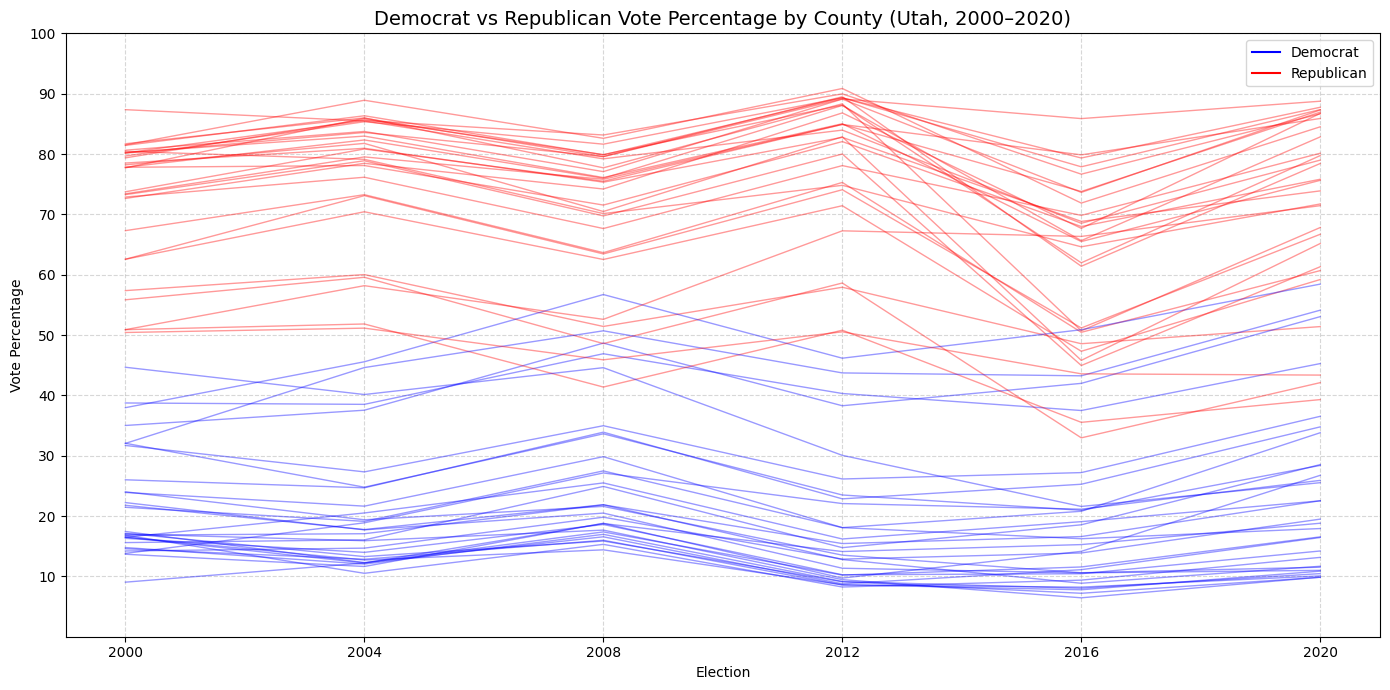

In [124]:
import matplotlib.pyplot as plt

utah_results = election_pivot[election_pivot['State'] == 'Utah']
utah_results = utah_results[['Year', 'County', 'Democrat Percentage', 'Republican Percentage']]
utah_results = utah_results.sort_values(by='Year')

# List of unique counties
counties = utah_results['County'].unique()

# Create the plot
plt.figure(figsize=(14, 7))

# Plot Democrat and Republican lines for each County
for County in counties:
    County_data = utah_results[utah_results['County'] == County]
    
    plt.plot(
        County_data['Year'], 
        County_data['Democrat Percentage'], 
        color='blue', 
        alpha=0.4, 
        linewidth=1
    )
    
    plt.plot(
        County_data['Year'], 
        County_data['Republican Percentage'], 
        color='red', 
        alpha=0.4, 
        linewidth=1
    )

# Add single legend entries (dummy lines)
plt.plot([], [], color='blue', label='Democrat')
plt.plot([], [], color='red', label='Republican')

# Final plot formatting
plt.title('Democrat vs Republican Vote Percentage by County (Utah, 2000–2020)', fontsize=14)
plt.xlabel('Election')
plt.ylabel('Vote Percentage')
plt.xticks([2000, 2004, 2008, 2012, 2016, 2020])
plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Utah is a reliably conservative state, and most of its counties vote overwhelmingly Republican. However, in 2016, many Utah conservatives were dissatisfied with GOP nominee Donald Trump and voted instead for Independent candidate Evan McMullin. Thus, Republican vote shares drastically drop without Democratic vote shares meaningfully increasing. In 2020, most of these dissident conservatives returned "home" and supported Trump. Because this "blip" essentially reversed itself in just one election cycle, it seems the models were not well able to account for it.

# Idaho
Idaho also several heavily Mormon counties. Are there similar trends

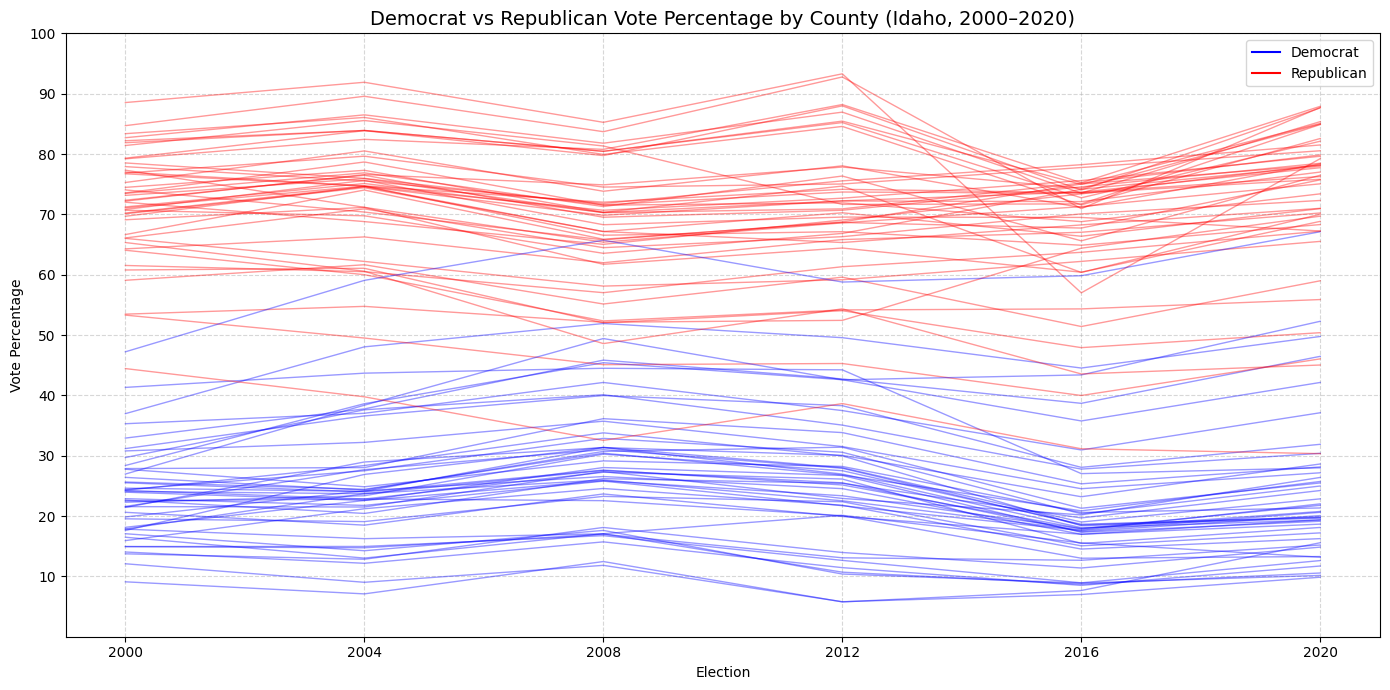

In [231]:
import matplotlib.pyplot as plt

idaho_results = election_pivot[election_pivot['State'] == 'Idaho']
idaho_results = idaho_results[['Year', 'County', 'Democrat Percentage', 'Republican Percentage']]
idaho_results = idaho_results.sort_values(by='Year')

# List of unique counties
counties = idaho_results['County'].unique()

# Create the plot
plt.figure(figsize=(14, 7))

# Plot Democrat and Republican lines for each County
for County in counties:
    County_data = idaho_results[idaho_results['County'] == County]
    
    plt.plot(
        County_data['Year'], 
        County_data['Democrat Percentage'], 
        color='blue', 
        alpha=0.4, 
        linewidth=1
    )
    
    plt.plot(
        County_data['Year'], 
        County_data['Republican Percentage'], 
        color='red', 
        alpha=0.4, 
        linewidth=1
    )

# Add single legend entries (dummy lines)
plt.plot([], [], color='blue', label='Democrat')
plt.plot([], [], color='red', label='Republican')

# Final plot formatting
plt.title('Democrat vs Republican Vote Percentage by County (Idaho, 2000–2020)', fontsize=14)
plt.xlabel('Election')
plt.ylabel('Vote Percentage')
plt.xticks([2000, 2004, 2008, 2012, 2016, 2020])
plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Texas
Texas has many heavily Hispanic counties which shifted dramatically toward Republicans in 2020.

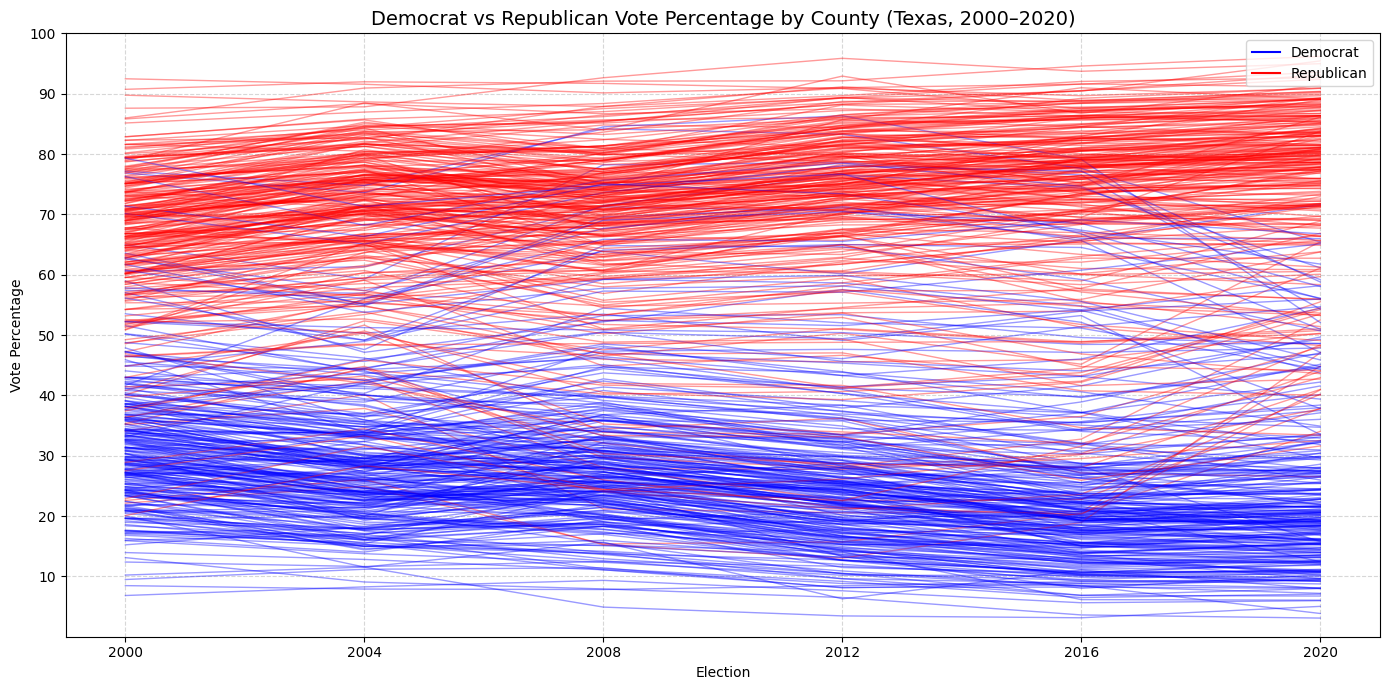

In [232]:
import matplotlib.pyplot as plt

texas_results = election_pivot[election_pivot['State'] == 'Texas']
texas_results = texas_results[['Year', 'County', 'Democrat Percentage', 'Republican Percentage']]
texas_results = texas_results.sort_values(by='Year')

# List of unique counties
counties = texas_results['County'].unique()

# Create the plot
plt.figure(figsize=(14, 7))

# Plot Democrat and Republican lines for each County
for County in counties:
    County_data = texas_results[texas_results['County'] == County]
    
    plt.plot(
        County_data['Year'], 
        County_data['Democrat Percentage'], 
        color='blue', 
        alpha=0.4, 
        linewidth=1
    )
    
    plt.plot(
        County_data['Year'], 
        County_data['Republican Percentage'], 
        color='red', 
        alpha=0.4, 
        linewidth=1
    )

# Add single legend entries (dummy lines)
plt.plot([], [], color='blue', label='Democrat')
plt.plot([], [], color='red', label='Republican')

# Final plot formatting
plt.title('Democrat vs Republican Vote Percentage by County (Texas, 2000–2020)', fontsize=14)
plt.xlabel('Election')
plt.ylabel('Vote Percentage')
plt.xticks([2000, 2004, 2008, 2012, 2016, 2020])
plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Colorado

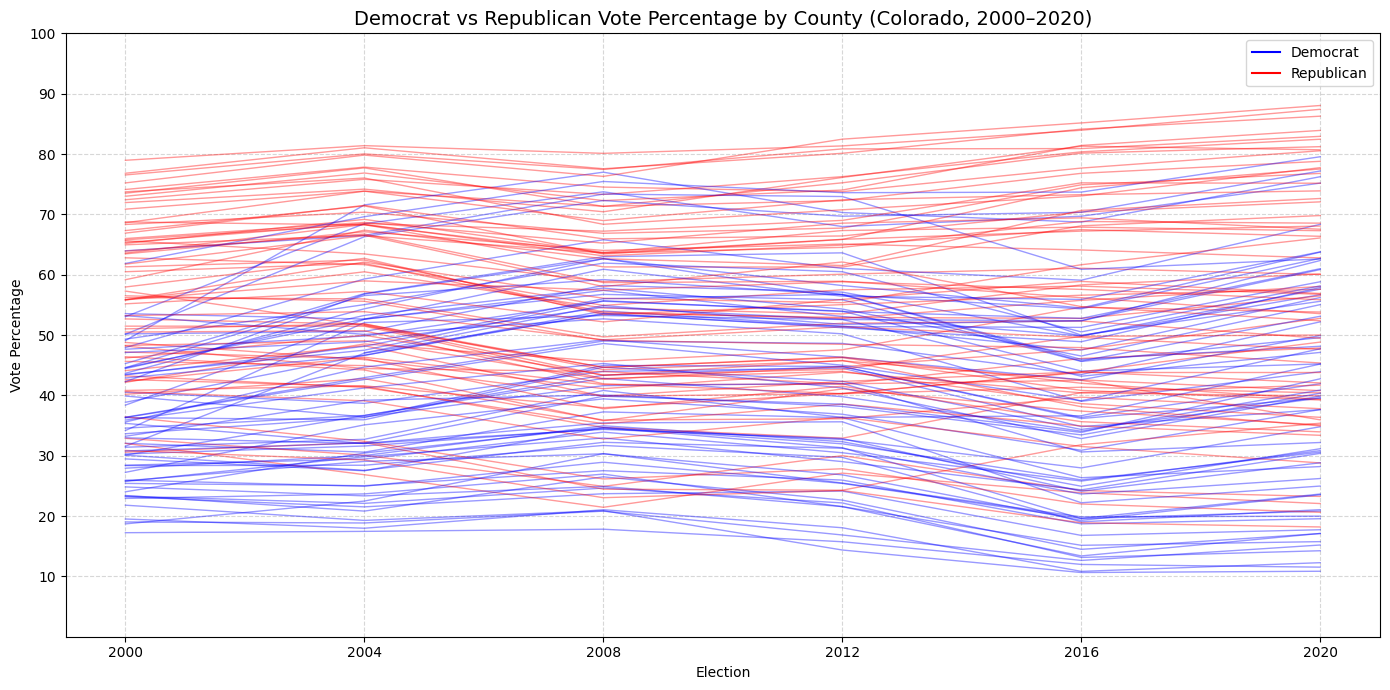

In [233]:
import matplotlib.pyplot as plt

colorado_results = election_pivot[election_pivot['State'] == 'Colorado']
colorado_results = colorado_results[['Year', 'County', 'Democrat Percentage', 'Republican Percentage']]
colorado_results = colorado_results.sort_values(by='Year')

# List of unique counties
counties = colorado_results['County'].unique()

# Create the plot
plt.figure(figsize=(14, 7))

# Plot Democrat and Republican lines for each County
for County in counties:
    County_data = colorado_results[colorado_results['County'] == County]
    
    plt.plot(
        County_data['Year'], 
        County_data['Democrat Percentage'], 
        color='blue', 
        alpha=0.4, 
        linewidth=1
    )
    
    plt.plot(
        County_data['Year'], 
        County_data['Republican Percentage'], 
        color='red', 
        alpha=0.4, 
        linewidth=1
    )

# Add single legend entries (dummy lines)
plt.plot([], [], color='blue', label='Democrat')
plt.plot([], [], color='red', label='Republican')

# Final plot formatting
plt.title('Democrat vs Republican Vote Percentage by County (Colorado, 2000–2020)', fontsize=14)
plt.xlabel('Election')
plt.ylabel('Vote Percentage')
plt.xticks([2000, 2004, 2008, 2012, 2016, 2020])
plt.yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()